In [1]:
import sys
sys.path.append('..')

In [2]:
import pandas as pd
from utils.data_enedis_ademe import DataEnedisAdeme

#### Consommation d'électricité annuelle résidentielle par adresse

*Le jeu de données présente la consommation électrique annuelle des adresses de 10 logements ou plus. Un logement correspond à un point de livraison (ou PDL) de type résidentiel.<br>Les données sont mises à disposition à titre purement indicatif sans garantie quant au degré de fiabilité des adresses. Enedis ne saurait, par conséquent, être tenue responsable en cas de défaut de fiabilité.<br>À partir de 2021 et suite à un changement dans le référentiel des adresses, la normalisation de celles-ci peut faire apparaitre des écarts avec les années précédentes.*

In [3]:
tmp_url = "https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?select=segment_de_client%2C%20annee%2C%20count\
    (code_iris)%20as%20nb%2C%20min(nombre_de_logements)%20as%20nb_min_logements%2C%20max(nombre_de_logements)%20as%20nb_max_logements&group_by=segment_de_client%2C%20annee&limit=20"

DataEnedisAdeme().load_get_data_pandas(tmp_url)

,segment_de_client,annee,nb,nb_min_logements,nb_max_logements
0,RESIDENTIEL,2018-01-01T00:00:00+00:00,391099,10,1189
1,RESIDENTIEL,2019-01-01T00:00:00+00:00,399791,10,1124
2,RESIDENTIEL,2020-01-01T00:00:00+00:00,405605,10,1435
3,RESIDENTIEL,2021-01-01T00:00:00+00:00,407053,10,1189
4,RESIDENTIEL,2022-01-01T00:00:00+00:00,394100,10,1190
5,RESIDENTIEL,2023-01-01T00:00:00+00:00,397398,10,1196


*Avec ceci on voit que les adresses Enedis sont des logements 'residentiels' avec au moins 10 logements et au plus +de 1000 logements. Une fois la correspondance faite avec la base de l'ADEME - DPE depuis 2021 on le dataset suivant :*

In [4]:
db = DataEnedisAdeme()
tmp_df = db.extract_sample_year_rows(year=2023, rows=5)
tmp_df.head(3)

 https://data.enedis.fr/api/explore/v2.1/catalog/datasets/consommation-annuelle-residentielle-par-adresse/records?where=annee%20%3D%20date'2023'&limit=5


,Conso_chauffage_dépensier_é_finale_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Coût_total_5_usages_ademe,Coordonnée_cartographique_X_(BAN)_ademe,Nombre_niveau_logement_ademe,Apports_internes_saison_froid_ademe,...,x_enedis_with_ban,y_enedis_with_ban,city_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,_type_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban
0,14842.3,Cavaillon,3195.3,1704.1,1704.1,0,1846.3,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,address,5.041736,43.834389
1,8112.0,Cavaillon,604.4,NaN,1632.0,0,1572.0,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,address,5.041736,43.834389
2,11200.8,Cavaillon,2415.7,0.0,1863.6,0,1125.0,864217.4,1,0.0,...,864217.4,6306054.04,Cavaillon,"84, Vaucluse, Provence-Alpes-Côte d'Azur",housenumber,0.65173,Avenue du Maréchal Joffre,address,5.041736,43.834389


*Echantillon pour l'étude : périmètre Paris 2018*

In [5]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2018_400k_rows_250_min_comp.parquet', engine='pyarrow')
df.head()

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Nom__commune_(BAN)_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Besoin_refroidissement_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,...,y_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,16170.8,0.0,1548.3,Paris,2987.6,0.0,1548.3,0,16170.8,1083.0,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
1,20081.5,0.0,5617.0,Paris,3737.2,0.0,5617.0,0,20081.5,2150.5,...,6866570.89,Paris,Paris 17e Arrondissement,"75, Paris, Île-de-France",housenumber,0.66547,Passage Flourens,2.327087,48.897252,None
2,38501.7,0.0,5812.1,Paris,10285.3,0.0,5812.1,0,38501.7,3529.6,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
3,39468.7,0.0,6130.1,Paris,10508.7,0.0,6130.1,0,39468.7,3637.1,...,6863733.09,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.278373,48.871447,address
4,15376.1,0.0,5752.4,Paris,2816.4,0.0,5752.4,0,15376.1,1186.5,...,6863783.96,Paris,Paris 16e Arrondissement,"75, Paris, Île-de-France",housenumber,0.77255,Avenue Foch,2.282777,48.871931,None


# Exploration

In [ ]:
class nettoyage :
    def __init__(self, df):
        self.df = df.copy()
        
    def delete_colnan (self, tauxseuil):
        print("Le dataframe contient initialement ",len(self.df.columns)," colonnes.")
        print("Start processing : columns identification ...")
        for c in df.columns:
            tauxnan = round(df[c].isna().sum()/len(df),2)
            nanames = []
            if tauxnan >= tauxseuil:
                nanames.extend(c)
                # print("***", c, "***")
                # print(tauxnan)
        print("Il y a {} colonnes vides à au moins {}% ".format(len(nanames),tauxseuil*100))
        print("Start processing : columns deleting ...")
        df_clean=df.drop(nanames, axis=1)
        print("Done")
        print("Il reste {} colonnes".format(len()df_clean))
        return df_clean
    


In [31]:
# recherches des valeurs manquantes
tauxseuil = 0.9
nanames = []
for c in df.columns:
    tauxnan = round(df[c].isna().sum()/len(df),2)
    if tauxnan >= tauxseuil:
        nanames.append(c)
        #print("***", c, "***")
        #print(tauxnan)
print("Il y a {} colonnes vides à au moins {}% ".format(len(nanames),tauxseuil*100))
# print(len(df.columns))
# print(nanames)
df_clean = df.copy().drop(nanames, axis=1)


le nombre de colonnes vides à au moins 50%:
 76
Il y a 76 colonnes vides à au moins 90.0% 


In [32]:
round(df_clean.describe(),2)

,Conso_chauffage_dépensier_é_finale_ademe,Volume_stockage_générateur_ECS_n°1_ademe,Conso_é_finale_installation_ECS_ademe,Emission_GES_chauffage_ademe,Conso_ECS_é_finale_énergie_n°2_ademe,Conso_ECS_é_finale_énergie_n°1_ademe,Conso_chauffage_dépensier_installation_chauffage_n°1_ademe,Coût_total_5_usages_ademe,Conso_é_finale_dépensier_installation_ECS_ademe,Surface_chauffée_installation_chauffage_n°1_ademe,...,Code EPCI_enedis_with_ban,Code Département_enedis_with_ban,Code Région_enedis_with_ban,Tri des adresses_enedis_with_ban,score_enedis_with_ban,x_enedis_with_ban,y_enedis_with_ban,importance_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban
count,465961.00,452514.00,452514.00,465961.00,285178.00,465961.00,454586.00,465959.00,452514.00,454586.00,...,465961.0,465961.0,465961.0,465961.00,465961.00,465961.00,465961.00,465961.00,465961.00,465961.00
mean,14104.16,161.83,77260.46,2097.49,614.24,3158.54,299213.56,1665.70,107997.09,1777.23,...,200054781.0,75.0,11.0,653502.08,0.73,651880.87,6862249.72,0.74,2.34,48.86
std,77390.94,687.99,195279.17,12647.30,6353.98,19472.20,812061.14,8103.75,273921.80,4366.07,...,0.0,0.0,0.0,14243.57,0.03,2979.47,2417.92,0.06,0.04,0.02
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,41.00,0.00,0.30,...,200054781.0,75.0,11.0,628981.00,0.45,645307.24,6857682.68,0.48,2.25,48.82
25%,3719.90,0.00,1439.10,264.40,0.00,1285.80,4163.30,674.20,1866.50,31.00,...,200054781.0,75.0,11.0,641089.00,0.72,649390.73,6860189.82,0.70,2.31,48.84
50%,6674.60,40.00,1934.00,731.80,0.00,1702.50,8762.80,967.60,2523.05,55.00,...,200054781.0,75.0,11.0,653553.00,0.74,652186.95,6862109.43,0.74,2.35,48.86
75%,12039.80,100.00,5502.72,1928.40,0.00,2359.50,29887.62,1340.90,7606.10,548.80,...,200054781.0,75.0,11.0,665761.00,0.75,654286.90,6864345.32,0.79,2.38,48.88
max,7108617.20,65000.00,2154610.20,1177726.80,605106.40,2154610.20,6782825.60,751160.00,3039539.30,39182.00,...,200054781.0,75.0,11.0,679041.00,0.81,657143.08,6867011.10,0.85,2.42,48.90


<BarContainer object of 7 artists>

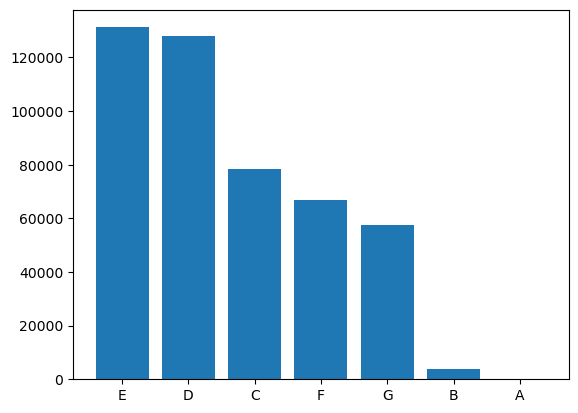

In [46]:
# distribution des logements en fonction des DPE
import matplotlib.pyplot as plt
import numpy as np

DPE = df["Etiquette_DPE_ademe"].value_counts().index
count = df["Etiquette_DPE_ademe"].value_counts()
fig, ax = plt.subplots()
ax.bar(DPE,count)

In [54]:
df["Consommation annuelle moyenne par logement de l'adresse (MWh)_enedis_with_ban"].values

array([1.694, 1.694, 2.965, ..., 3.132, 3.132, 3.132])

In [ ]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])  # Plot some data on the Axes.
plt.show()                           # Show the figure.

#### explore

In [2]:
import pandas as pd

In [4]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')
df.shape

(464576, 280)

In [5]:
df.dtypes.unique()

array([dtype('float64'), dtype('O'), dtype('int64')], dtype=object)

In [21]:
import re
from unidecode import unidecode
from functools import lru_cache

@lru_cache(maxsize=1024)
def normalize_name(colname):
    pat1, pat2 = re.compile('[^0-9a-zA-Z]+'), re.compile('_+')
    return pat1.sub('_', pat2.sub('_', colname))

def normalize_df_colnames(df):
    return df.rename(columns={c: normalize_name(unidecode(c)).lower() for c in df.columns})

df1 = normalize_df_colnames(df.copy())

In [23]:
df1.dtypes.unique()

array([dtype('float64'), dtype('O'), dtype('int64')], dtype=object)

### gerer les types

In [40]:
import warnings 
warnings.filterwarnings('ignore')

dfobj = df1.select_dtypes(include='O')
dfobj = dfobj.replace(',', '.')
for c in dfobj:
    dfobj[c] = dfobj[c].fillna(-99999)
    try:
        dfobj[c] = pd.to_numeric(dfobj[c], errors='raise')
    except Exception as e:
        try:
            dfobj[c] = pd.to_datetime(dfobj[c])
        except Exception as e:
            dfobj[c] = dfobj[c].astype('str')

In [41]:
dfobj.dtypes.unique()

array([dtype('O'), dtype('<M8[ns]'), dtype('int64')], dtype=object)

In [46]:
dfobj.select_dtypes(include=['object']).head()

,nom_commune_ban_ademe,besoin_refroidissement_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,type_installation_ecs_general_ademe,usage_generateur_ecs_ndeg1_ademe,adresse_ban_ademe,type_energie_generateur_ecs_ndeg1_ademe,complement_d_adresse_logement_ademe,...,label_enedis_with_ban,housenumber_enedis_with_ban,id_ban_enedis_with_ban,name_enedis_with_ban,city_enedis_with_ban,district_enedis_with_ban,context_enedis_with_ban,type_enedis_with_ban,street_enedis_with_ban,_type_enedis_with_ban
0,Paris,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,chauffage + ecs,108 Rue de Rennes 75006 Paris,Gaz naturel,Etage 5,...,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,Rue de Rennes,-99999
1,Paris,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,Électricité,7ème étage,...,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,Rue de Rennes,-99999
2,Paris,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,Électricité,3ème sur cour,...,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,Rue de Rennes,-99999
3,Paris,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,Électricité,7ème étage,...,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,Rue de Rennes,-99999
4,Paris,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,Électricité,7ème étage,...,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris,Paris 6e Arrondissement,"75, Paris, Île-de-France",housenumber,Rue de Rennes,-99999


In [49]:
import numpy as np

def get_entropy(pk, L):
        op = - (pk * np.log(pk) / np.log(L)).sum()
        return op
# pk : probabilité de chaque valeur
# L : nombre de valeurs possibles
# d : dataframe
# cols : liste des colonnes à traiter
 
def compute_entropies(d, cols):
    entropies = []
    for i,col in enumerate(cols):
        pk = d[col].value_counts(normalize=True, dropna = False).values
        entropy = round(get_entropy(pk, len(d)),2)
        entropies.append({"col": col, "entropy": entropy})
    return entropies      
 
df_entropy = pd.DataFrame(compute_entropies(dfobj, dfobj.columns))
df_entropy.sort_values(by="entropy", ascending=False)

,col,entropy
16,ndegdpe_ademe,0.99
64,_id_ademe,0.99
18,adresse_brute_ademe,0.82
7,adresse_ban_ademe,0.75
114,adresse_enedis_with_ban,0.75
...,...,...
98,type_installation_solaire_ademe,0.00
112,nom_commune_enedis_with_ban,-0.00
113,segment_de_client_enedis_with_ban,-0.00
120,city_enedis_with_ban,-0.00


In [50]:
df_entropy[df_entropy['entropy']==0]

,col,entropy
0,nom_commune_ban_ademe,0.0
24,modele_dpe_ademe,-0.0
27,ndeg_departement_ban_ademe,0.0
29,ndeg_region_ban_ademe,0.0
32,classe_altitude_ademe,0.0
46,zone_climatique_ademe,0.0
63,_score_ademe,-0.0
79,type_generateur_froid_ademe,0.0
80,periode_installation_generateur_froid_ademe,0.0
81,type_energie_climatisation_ademe,0.0


In [52]:
dfobj.type_generateur_froid_ademe.value_counts()

type_generateur_froid_ademe
-99999                                           460748
PAC air/air installée à partir de 2015             1573
PAC air/air installée avant 2008                   1197
PAC air/air installée entre 2008 et 2014            506
PAC air/eau installée avant 2008                    172
PAC air/eau installée après 2017                    116
PAC air/eau installée entre 2008 et 2014             47
autre système thermodynamique électrique             47
PAC air/eau installée entre 2015 et 2016             42
autre système de refroidissement                     38
PAC eau/eau installée après 2017                     35
PAC eau/eau installée avant 2008                     24
PAC eau/eau installée entre 2008 et 2014              8
autre système thermodynamique gaz                     6
réseau de froid urbain                                6
PAC eau/eau installée entre 2015 et 2016              5
PAC géothermique installée avant 2008                 3
PAC géothermique ins

In [57]:
cols_to_del = list(df_entropy[df_entropy['entropy']==0]['col'].values)
dfobj.copy().drop(cols_to_del, axis=1).head()

,besoin_refroidissement_ademe,configuration_installation_chauffage_ndeg1_ademe,configuration_installation_ecs_ademe,type_installation_chauffage_ndeg1_ademe,type_installation_ecs_general_ademe,usage_generateur_ecs_ndeg1_ademe,adresse_ban_ademe,date_visite_diagnostiqueur_ademe,type_energie_generateur_ecs_ndeg1_ademe,complement_d_adresse_logement_ademe,...,adresse_enedis_with_ban,full_adress_enedis_with_ban,label_enedis_with_ban,housenumber_enedis_with_ban,id_ban_enedis_with_ban,name_enedis_with_ban,district_enedis_with_ban,type_enedis_with_ban,street_enedis_with_ban,_type_enedis_with_ban
0,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,chauffage + ecs,108 Rue de Rennes 75006 Paris,2024-05-02,Gaz naturel,Etage 5,...,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris 6e Arrondissement,housenumber,Rue de Rennes,-99999
1,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,2022-08-22,Électricité,7ème étage,...,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris 6e Arrondissement,housenumber,Rue de Rennes,-99999
2,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,2023-09-11,Électricité,3ème sur cour,...,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris 6e Arrondissement,housenumber,Rue de Rennes,-99999
3,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,2022-08-22,Électricité,7ème étage,...,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris 6e Arrondissement,housenumber,Rue de Rennes,-99999
4,0,Installation de chauffage simple,Un seul système d'ECS sans solaire,installation individuelle,individuel,ecs,108 Rue de Rennes 75006 Paris,2022-08-22,Électricité,7ème étage,...,108 RUE DE RENNES,108 RUE DE RENNES 75056 Paris,108 RUE DE RENNES 75006 PARIS,108,75106_8151_00108,108 Rue de Rennes,Paris 6e Arrondissement,housenumber,Rue de Rennes,-99999


In [58]:
[c for c in df if 'geo' in c]

['_geopoint_ademe']

exclure les variables

In [21]:
import warnings 
import numpy as np, pandas as pd


warnings.filterwarnings('ignore')

def get_entropy(pk, L):
    # pk : probabilité de chaque valeur
    # L : nombre de valeurs possibles
    # d : dataframe
    # cols : liste des colonnes à traiter
    op = - (pk * np.log(pk) / np.log(L)).sum()
    return op
 
def compute_entropies(d, cols):
    print('Computing entropies..')
    entropies = []
    for i,col in enumerate(cols):
        pk = d[col].value_counts(normalize=True, dropna = False).values
        entropy = round(get_entropy(pk, len(d)),2)
        entropies.append({"col": col, "entropy": entropy})
    return entropies      

import re
from unidecode import unidecode
from functools import lru_cache

@lru_cache(maxsize=1024)
def normalize_name(colname):
    pat1, pat2 = re.compile('[^0-9a-zA-Z]+'), re.compile('_+')
    return pat1.sub('_', pat2.sub('_', colname))

def normalize_df_colnames(df):
    return df.rename(columns={c: normalize_name(unidecode(c)).lower() for c in df.columns})

class Nettoyage:

    def __init__(self, df):
        self.df = df
        self.cols_to_delete = set()
        self.df_entropies = None
        self.delete_colnan_step = False
        self.fillna_step = False
        self.cast_object_columns_step = False
        self.delete_based_on_entropies_step = False
        
    def delete_colnan(self, tauxseuil=0.9):
        nanames, entro, extra = [], [], []
        if not self.delete_colnan_step:
            print("Le dataframe contient initialement ", len(self.df.columns)," colonnes.")
            print("Start processing : columns identification..")
            for c in self.df.columns:
                tauxnan = round(self.df[c].isna().sum()/len(self.df),2)
                pk = df[c].value_counts(normalize=True, dropna = False).values
                entropy = round(get_entropy(pk, len(df)),2)
                if tauxnan >= tauxseuil:
                    nanames.append(c)
                if c.startswith('_') and ('geo' not in c.lower()):
                    extra.append(c)
                if entropy == 1 or entropy == 0:
                    entro.append(c)
            
            print("Il y a {} colonnes vides avec au moins {}% , {} colonnes avec une entropy de 1 ou 0 et {} colonnes inutiles.".format(len(nanames),tauxseuil*100, len(entro), len(extra)))
            self.cols_to_delete.update(nanames+extra+entro)
            if len(self.cols_to_delete) > 0:
                print("Start processing : columns deleting ...")
                self.df = self.df.drop(list(self.cols_to_delete), axis=1)
                print("Done")
                print(f"Il reste {len(self.df.columns)} colonnes.")
            self.delete_colnan_step = True
        return self
        

    def cast_object_columns(self):
        if not self.cast_object_columns_step:
            cols_obj = self.df.select_dtypes(include='O').columns
            for c in cols_obj:
                self.df[c] = self.df[c].replace(',', '.')
                # self.df[c] = self.df[c].fillna(-999999)
                try:
                    self.df[c] = pd.to_numeric(self.df[c], errors='raise')
                except Exception as e:
                    try:
                        self.df[c] = pd.to_datetime(self.df[c])
                    except Exception as e:
                        self.df[c] = self.df[c].astype('string')
            print("Casting done...")
            self.cast_object_columns_step = True
        return self
    
    def delete_based_on_entropies(self): # calculer sur un process à part # delete
        if not self.delete_based_on_entropies_step:
            self.df_entropies = pd.DataFrame(compute_entropies(self.df, self.df.columns))
            self.df_entropies = self.df_entropies.sort_values(by="entropy", ascending=False)
            col_with_null_entropies = list(self.df_entropies[self.df_entropies['entropy']==0]['col'].values)
            print(f"Il y a {len(col_with_null_entropies)} cols avec entropies nulles.")
            self.cols_to_delete.update(col_with_null_entropies)
            self.df = self.df.drop(col_with_null_entropies, axis=1)
            self.delete_based_on_entropies_step = True
        return self

    def run(self):
        self.delete_colnan().cast_object_columns()

In [22]:
df = pd.read_parquet('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')

In [23]:
pipeline = Nettoyage(df)
pipeline.run() # 1min

Le dataframe contient initialement  280  colonnes.
Start processing : columns identification..
Il y a 76 colonnes vides avec au moins 90.0% , 55 colonnes avec une entropy de 1 ou 0 et 5 colonnes inutiles.
Start processing : columns deleting ...
Done
Il reste 183 colonnes.
Casting done...


In [24]:
df = pipeline.df
del pipeline

In [25]:
df = normalize_df_colnames(df)

In [18]:
df.head()

,conso_chauffage_depensier_e_finale_ademe,volume_stockage_generateur_ecs_ndeg1_ademe,conso_e_finale_installation_ecs_ademe,emission_ges_chauffage_ademe,conso_ecs_e_finale_energie_ndeg2_ademe,conso_ecs_e_finale_energie_ndeg1_ademe,besoin_refroidissement_ademe,conso_chauffage_depensier_installation_chauffage_ndeg1_ademe,cout_total_5_usages_ademe,configuration_installation_chauffage_ndeg1_ademe,...,citycode_enedis_with_ban,x_enedis_with_ban,y_enedis_with_ban,district_enedis_with_ban,type_enedis_with_ban,importance_enedis_with_ban,street_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,_type_enedis_with_ban
0,25827.1,0.0,2621.9,4670.2,0.0,2621.9,0,25827.1,1962.0,Installation de chauffage simple,...,75106,650709.85,6861175.94,Paris 6e Arrondissement,housenumber,0.71698,Rue de Rennes,2.328325,48.84874,-999999
1,1318.3,100.0,1153.0,79.4,NaN,1153.0,0,1318.3,458.0,Installation de chauffage simple,...,75106,650709.85,6861175.94,Paris 6e Arrondissement,housenumber,0.71698,Rue de Rennes,2.328325,48.84874,-999999
2,49222.4,100.0,1772.3,8796.8,3046.7,0.0,0,47488.7,3705.1,Installation de chauffage simple,...,75106,650709.85,6861175.94,Paris 6e Arrondissement,housenumber,0.71698,Rue de Rennes,2.328325,48.84874,-999999
3,2468.6,100.0,1150.6,153.9,NaN,1150.6,0,2468.6,598.1,Installation de chauffage simple,...,75106,650709.85,6861175.94,Paris 6e Arrondissement,housenumber,0.71698,Rue de Rennes,2.328325,48.84874,-999999
4,2526.3,100.0,1132.2,157.8,NaN,1132.2,0,2526.3,602.4,Installation de chauffage simple,...,75106,650709.85,6861175.94,Paris 6e Arrondissement,housenumber,0.71698,Rue de Rennes,2.328325,48.84874,-999999


In [ ]:
df.info() # de 1gb à 700mb # 650mb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464576 entries, 0 to 464575
Columns: 183 entries, conso_chauffage_depensier_e_finale_ademe to lat_enedis_with_ban
dtypes: datetime64[ns](4), float64(105), int64(14), string(60)
memory usage: 648.6 MB


In [28]:
df.dtypes.unique()

array([dtype('float64'), string[python], dtype('<M8[ns]'), dtype('int64')],
      dtype=object)

#### 27/01

In [31]:
import pandas as pd

df = pd.read_parquet('../ressources/data/3_cleaned/2025_01_15/enedis_ban_ademe_extract_PARIS_2022.parquet')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464576 entries, 0 to 464575
Columns: 183 entries, conso_chauffage_depensier_e_finale_ademe to lat_enedis_with_ban
dtypes: datetime64[ns](4), float64(111), int64(8), string(60)
memory usage: 648.6 MB


In [33]:
_conso_cols_enedis = list(filter(lambda c: ('conso' in c.lower()) and ('enedis' in c.lower()), df.columns))
_conso_cols_ademe = list(filter(lambda c: ('conso' in c.lower()) and ('ademe' in c.lower()), df.columns))
_dpe_cols = list(filter(lambda c: ('dpe' in c.lower()), df.columns))
_deperdition_cols = list(filter(lambda c: ('deperdition' in c.lower()), df.columns))

_tmp_cols = _conso_cols_ademe + _conso_cols_enedis + _dpe_cols + _deperdition_cols
_others = list(filter(lambda c: c not in _tmp_cols, df.columns))
del _tmp_cols

In [3]:
variables = dict()

### Target

In [4]:
df['consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'] = df['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'] * 1000 # conversion mwh -> kwh
_conso_cols_enedis.append('consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban')

In [54]:
round(df[_conso_cols_enedis].describe(), 2) # garder la conso moyenne par logement car les données ademe sont au logement près

,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban
count,464576.00,464576.00,464576.00
mean,96.41,2.56,2555.31
std,101.70,1.31,1309.17
min,2.17,0.17,167.00
25%,40.72,1.62,1624.00
50%,65.23,2.27,2274.00
75%,108.87,3.10,3098.00
max,1218.59,16.92,16924.00


In [5]:
_target_col = ['consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'] # sur une année complète 12 mois à cause du terme annuelle

variables = dict()
variables.update({'target': _target_col})

In [56]:
df[_target_col].isna().sum()

consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban    0
dtype: int64

In [ ]:
import seaborn as sns

sns.histplot(df, x=_target_col[0])

#### features

In [27]:
df[_dpe_cols].dtypes

date_etablissement_dpe_ademe       datetime64[ns]
ndegdpe_ademe                      string[python]
methode_application_dpe_ademe      string[python]
date_reception_dpe_ademe           datetime64[ns]
date_fin_validite_dpe_ademe        datetime64[ns]
version_dpe_ademe                         float64
etiquette_dpe_ademe                string[python]
ndeg_dpe_immeuble_associe_ademe    string[python]
dtype: object

In [28]:
df[_dpe_cols].head()

,date_etablissement_dpe_ademe,ndegdpe_ademe,methode_application_dpe_ademe,date_reception_dpe_ademe,date_fin_validite_dpe_ademe,version_dpe_ademe,etiquette_dpe_ademe,ndeg_dpe_immeuble_associe_ademe
0,2024-05-04,2475E1621801Z,dpe appartement individuel,2024-05-05,2034-05-03,2.3,C,<NA>
1,2022-08-24,2275E1908696I,dpe appartement individuel,2022-08-25,2032-08-23,2.2,D,<NA>
2,2023-09-11,2375E3029709G,dpe appartement individuel,2023-09-12,2033-09-10,2.3,E,<NA>
3,2022-08-24,2275E1907878W,dpe appartement individuel,2022-08-25,2032-08-23,2.2,F,<NA>
4,2022-08-24,2275E1907880Y,dpe appartement individuel,2022-08-25,2032-08-23,2.2,F,<NA>


In [41]:
df['version_dpe_ademe'].value_counts() # quelle version du dpe retenir => utiliser ces colonnes là pour filtrer le dpe
                                       # finalité sortir une ou deux colonnes qui portent sur le dpe
df['date_etablissement_dpe_ademe'].min()

Timestamp('2021-06-30 00:00:00')

In [7]:
df['methode_application_dpe_ademe'].value_counts(dropna=False) 

methode_application_dpe_ademe
dpe appartement individuel                                                    304798
dpe appartement généré à partir des données DPE immeuble                      151927
dpe immeuble collectif                                                          6235
dpe maison individuelle                                                         1565
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : appartement        50
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : immeuble            1
Name: count, dtype: Int64

In [6]:
df['ndeg_dpe_immeuble_associe_ademe'].isna().sum()

np.int64(312873)

In [8]:
df[df['ndeg_dpe_immeuble_associe_ademe'].isna()==True]['methode_application_dpe_ademe'].value_counts()

methode_application_dpe_ademe
dpe appartement individuel                                                    304798
dpe immeuble collectif                                                          6231
dpe maison individuelle                                                         1565
dpe appartement généré à partir des données DPE immeuble                         228
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : appartement        50
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : immeuble            1
Name: count, dtype: Int64

In [9]:
df[df['ndeg_dpe_immeuble_associe_ademe'].isna()==False]['methode_application_dpe_ademe'].value_counts()

methode_application_dpe_ademe
dpe appartement généré à partir des données DPE immeuble    151699
dpe immeuble collectif                                           4
Name: count, dtype: Int64

In [12]:
import sys
sys.path.append('..')
from utils.fonctions import compute_cross_entropies

compute_cross_entropies(df, col_pairs=[('methode_application_dpe_ademe', 'ndeg_dpe_immeuble_associe_ademe'), ('ndeg_dpe_immeuble_associe_ademe', 'methode_application_dpe_ademe')])

Computing cross-entropies...


[{'col_pair': ('methode_application_dpe_ademe',
   'ndeg_dpe_immeuble_associe_ademe'),
  'cross_entropy': np.float64(34.5388)},
 {'col_pair': ('ndeg_dpe_immeuble_associe_ademe',
   'methode_application_dpe_ademe'),
  'cross_entropy': np.float64(11.2783)}]

- *Parmi les colonnes DPE on peut se passer des dates d'établissement, de réception J+1 et d'expiration du DPE pas nécéssaires dans la modélisation de la consommationd 'électricité.*
- *on pourrait garder le dpe de l'immeuble mais elle compte +300k de valeurs NA et le reste sont des DPE donc pas possible de faire une imputation. De plus, on voit que les logements pour lesquels cette variable est renseigné sont ceux pour lesquels on a le dpe appartement généré à partir des données DPE immeuble => en grande partie l'info que cette variable apporte est contenue dans celle de la variable `methode_application_dpe_ademe`*

In [6]:
_dpe_cols = list(filter(lambda c: ('date' not in c) and ('nde' not in c), _dpe_cols))
_dpe_cols

['methode_application_dpe_ademe', 'version_dpe_ademe', 'etiquette_dpe_ademe']

In [17]:
import sys
sys.path.append('..')
from utils.fonctions import compute_entropies

pd.DataFrame(compute_entropies(df, _dpe_cols))

Computing entropies..


,col,entropy
0,methode_application_dpe_ademe,0.06
1,version_dpe_ademe,0.12
2,etiquette_dpe_ademe,0.12


In [18]:
df[_dpe_cols].isna().sum()

methode_application_dpe_ademe    0
version_dpe_ademe                0
etiquette_dpe_ademe              0
dtype: int64

In [7]:
variables.update({"features": _dpe_cols})

In [25]:
variables

{'target': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'],
 'features': ['methode_application_dpe_ademe',
  'version_dpe_ademe',
  'etiquette_dpe_ademe']}

#### deperditions

In [34]:
_deperdition_cols

['deperditions_murs_ademe',
 'deperditions_planchers_bas_ademe',
 'deperditions_planchers_hauts_ademe',
 'deperditions_renouvellement_air_ademe',
 'deperditions_portes_ademe',
 'deperditions_baies_vitrees_ademe',
 'deperditions_ponts_thermiques_ademe',
 'deperditions_enveloppe_ademe']

In [28]:
df[_deperdition_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
deperditions_murs_ademe,463517.0,1577.242963,4000.856348,0.0,28.2,67.7,846.4,83500.5
deperditions_planchers_bas_ademe,463517.0,86.266430,202.910381,0.0,0.0,0.0,94.5,6723.1
deperditions_planchers_hauts_ademe,463517.0,171.791650,602.583890,0.0,0.0,0.0,115.0,130011.9
deperditions_renouvellement_air_ademe,463517.0,1738.571286,3786.193766,0.4,26.1,51.1,1485.2,29327.3
deperditions_portes_ademe,463517.0,28.852910,103.564526,0.0,0.0,1.7,5.6,2296.8
deperditions_baies_vitrees_ademe,463517.0,938.204485,2216.205172,0.0,13.3,30.9,718.5,58701.0
deperditions_ponts_thermiques_ademe,463517.0,806.881848,1918.937209,0.0,6.2,15.5,591.8,20119.4
deperditions_enveloppe_ademe,463517.0,5346.861888,11700.996462,4.1,88.6,172.8,4501.3,139266.0


In [8]:
variables['features'].extend(_deperdition_cols)

In [30]:
variables

{'target': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'],
 'features': ['methode_application_dpe_ademe',
  'version_dpe_ademe',
  'etiquette_dpe_ademe',
  'deperditions_murs_ademe',
  'deperditions_planchers_bas_ademe',
  'deperditions_planchers_hauts_ademe',
  'deperditions_renouvellement_air_ademe',
  'deperditions_portes_ademe',
  'deperditions_baies_vitrees_ademe',
  'deperditions_ponts_thermiques_ademe',
  'deperditions_enveloppe_ademe']}

#### consos ademe

In [32]:
len(_conso_cols_ademe)

34

In [33]:
df[_conso_cols_ademe].dtypes.unique()

array([dtype('float64')], dtype=object)

In [35]:
df = df[_conso_cols_ademe]
# df.info()

In [10]:
import matplotlib.pyplot as plt, seaborn as sns


def compute_pearson_correlation(df):
    """
    Calcule la corrélation de Pearson entre toutes les colonnes numériques d'un DataFrame.

    :param df: pd.DataFrame, DataFrame contenant les colonnes à analyser.
    :return: pd.DataFrame, matrice des corrélations de Pearson.
    """
    # Sélectionner uniquement les colonnes numériques (float ou int)
    numeric_df = df.select_dtypes(include=['float', 'int'])
    
    # Calcul de la matrice de corrélation
    correlation_matrix = numeric_df.corr(method='pearson')
    return correlation_matrix

def plot_upper_half_correlation_matrix(correlation_matrix):
    """
    Affiche une heatmap de la moitié supérieure d'une matrice de corrélation.

    :param correlation_matrix: pd.DataFrame, matrice des corrélations de Pearson.
    """
    # Masquer la moitié inférieure de la matrice
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    # Taille de la figure
    plt.figure(figsize=(10, 8))
    
    # Plot de la heatmap avec masque
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
                cbar_kws={'shrink': 0.8}, square=True, linewidths=0.5)
    
    plt.title('Upper Half of Pearson Correlation Matrix', fontsize=16)
    plt.show()

In [49]:
df = df[sorted(filter(lambda c: 'ndeg' not in c, _conso_cols_ademe))]
m_ = compute_pearson_correlation(df)

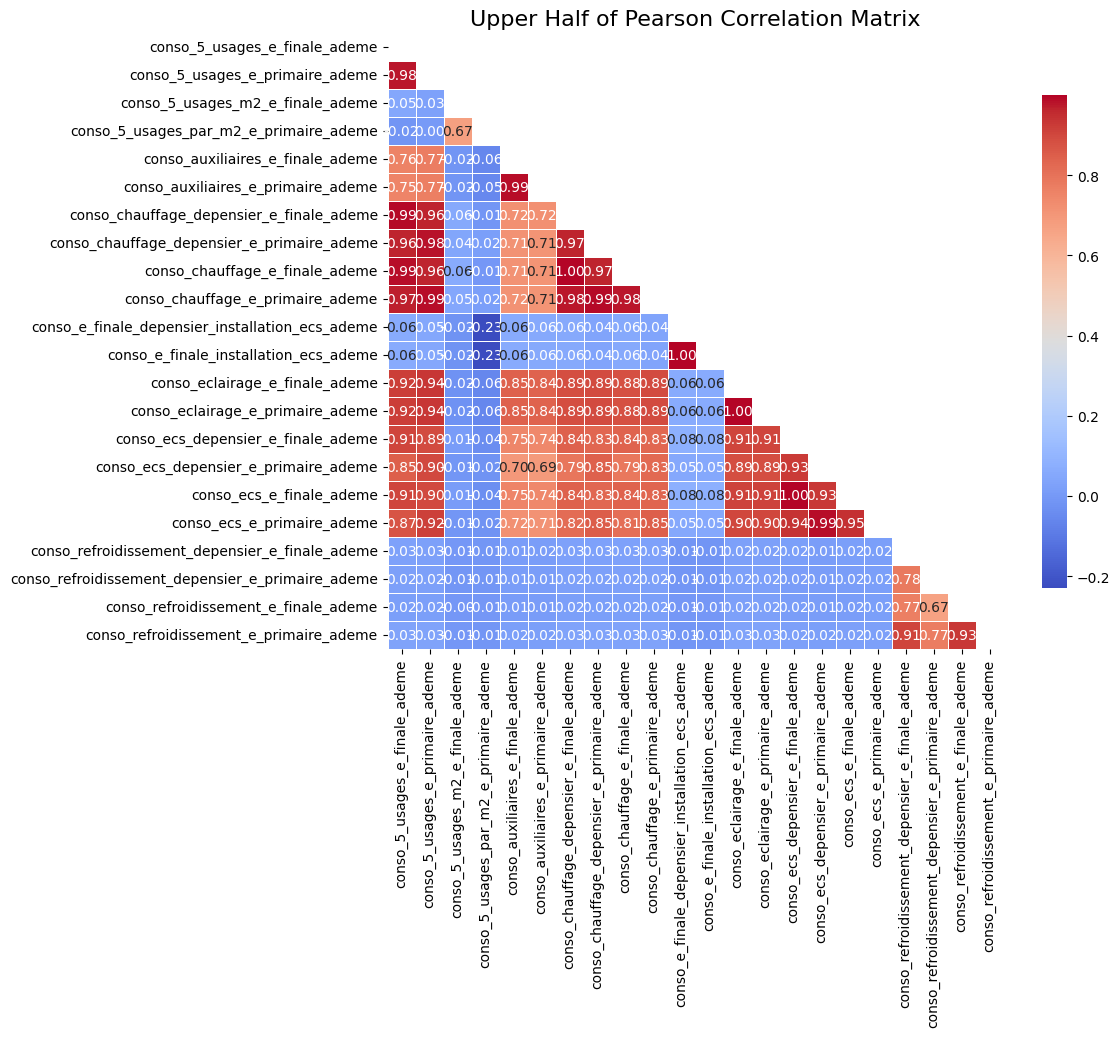

In [50]:
plot_upper_half_correlation_matrix(m_)

A cause de ceci https://www.bailfacile.fr/guides/dpe-energie-primaire-ou-finale, on sait que les DPE sont basé sur la conso primaire (correlation) et que la conso finale est celle utilisée pour fixer les plafonds de conso pour les passoires thermiques.

In [10]:
_conso_prim_cols_ademe = list(filter(lambda c: 'primaire' in c, _conso_cols_ademe))
_conso_fin_cols_ademe = list(filter(lambda c: 'finale' in c, _conso_cols_ademe))

In [1]:
import pandas as pd
df = pd.read_parquet('../ressources/data/3_cleaned/2025_01_15/enedis_ban_ademe_extract_PARIS_2022.parquet')

In [2]:
df = df[sorted(df.columns)]

In [5]:
_conso_fin_cols_ademe = list(filter(lambda c: ('finale' in c) and ('conso' in c), df.columns))
_target = ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban']

In [6]:
df1 = df[_target + _conso_fin_cols_ademe]

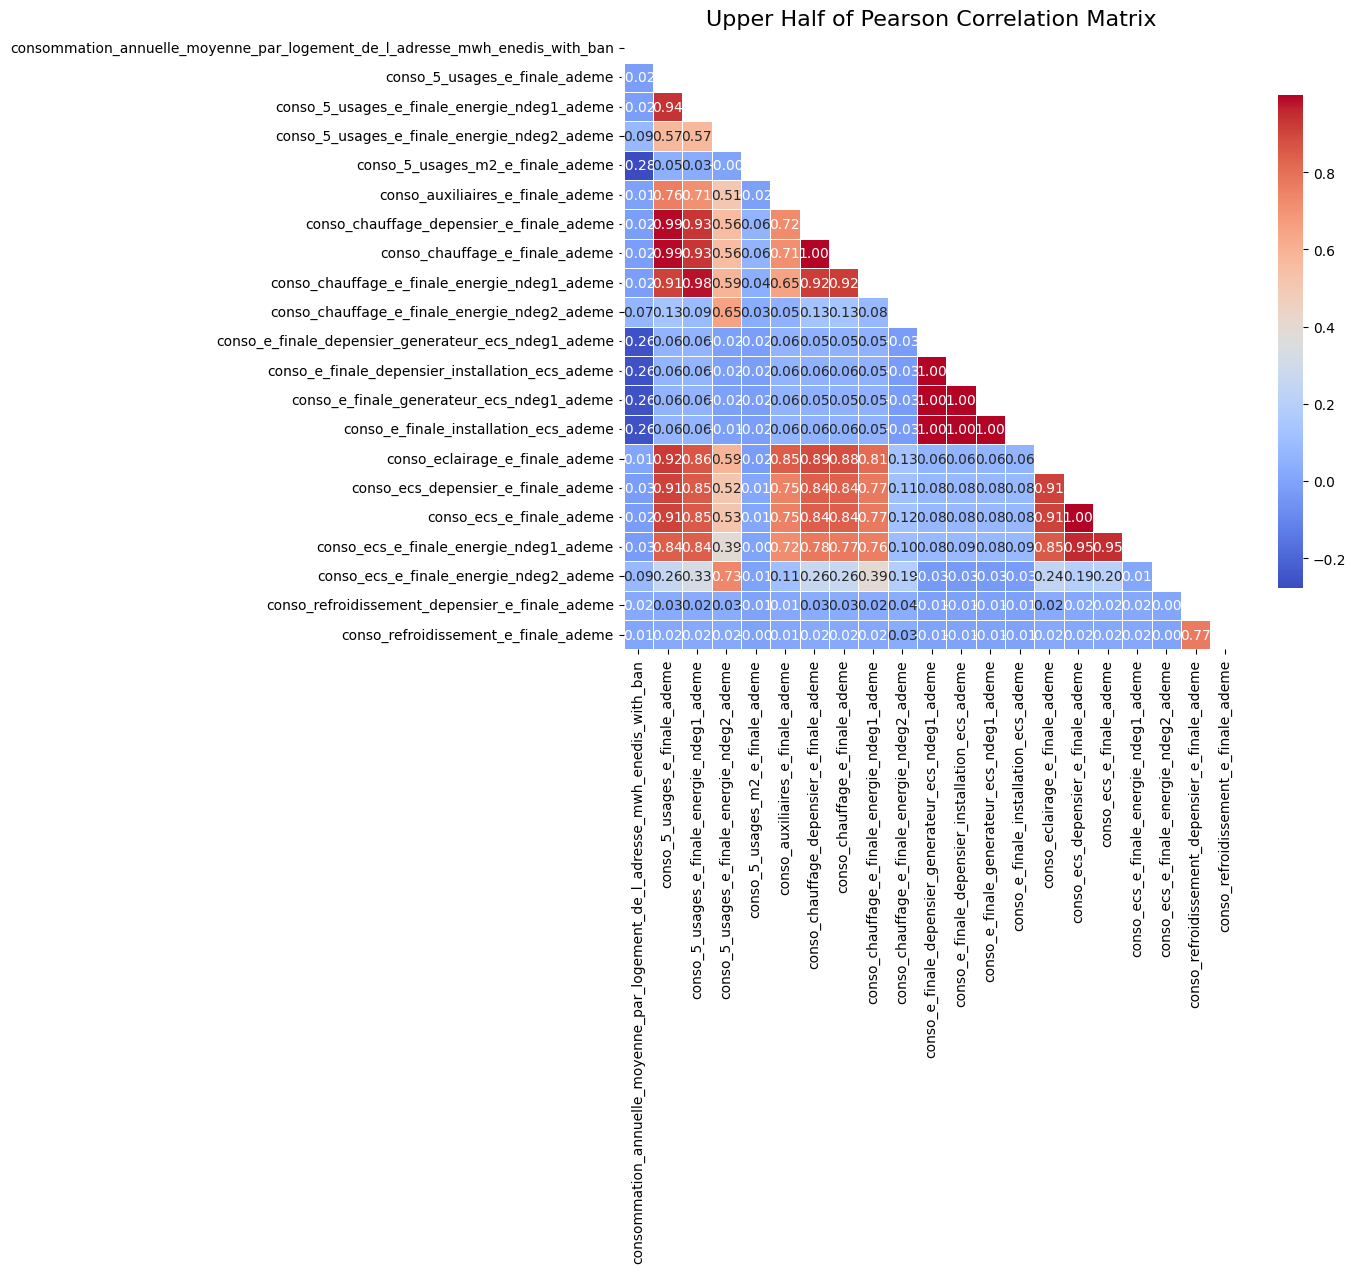

In [12]:
# corr mat conso finales
import numpy as np

plot_upper_half_correlation_matrix(compute_pearson_correlation(df1))

In [14]:
_conso_fin_cols_ademe = list(filter(lambda c: ('finale' in c) and ('conso' in c) and ('ndeg' not in c), _conso_fin_cols_ademe))
df2 = df1[_target + _conso_fin_cols_ademe]

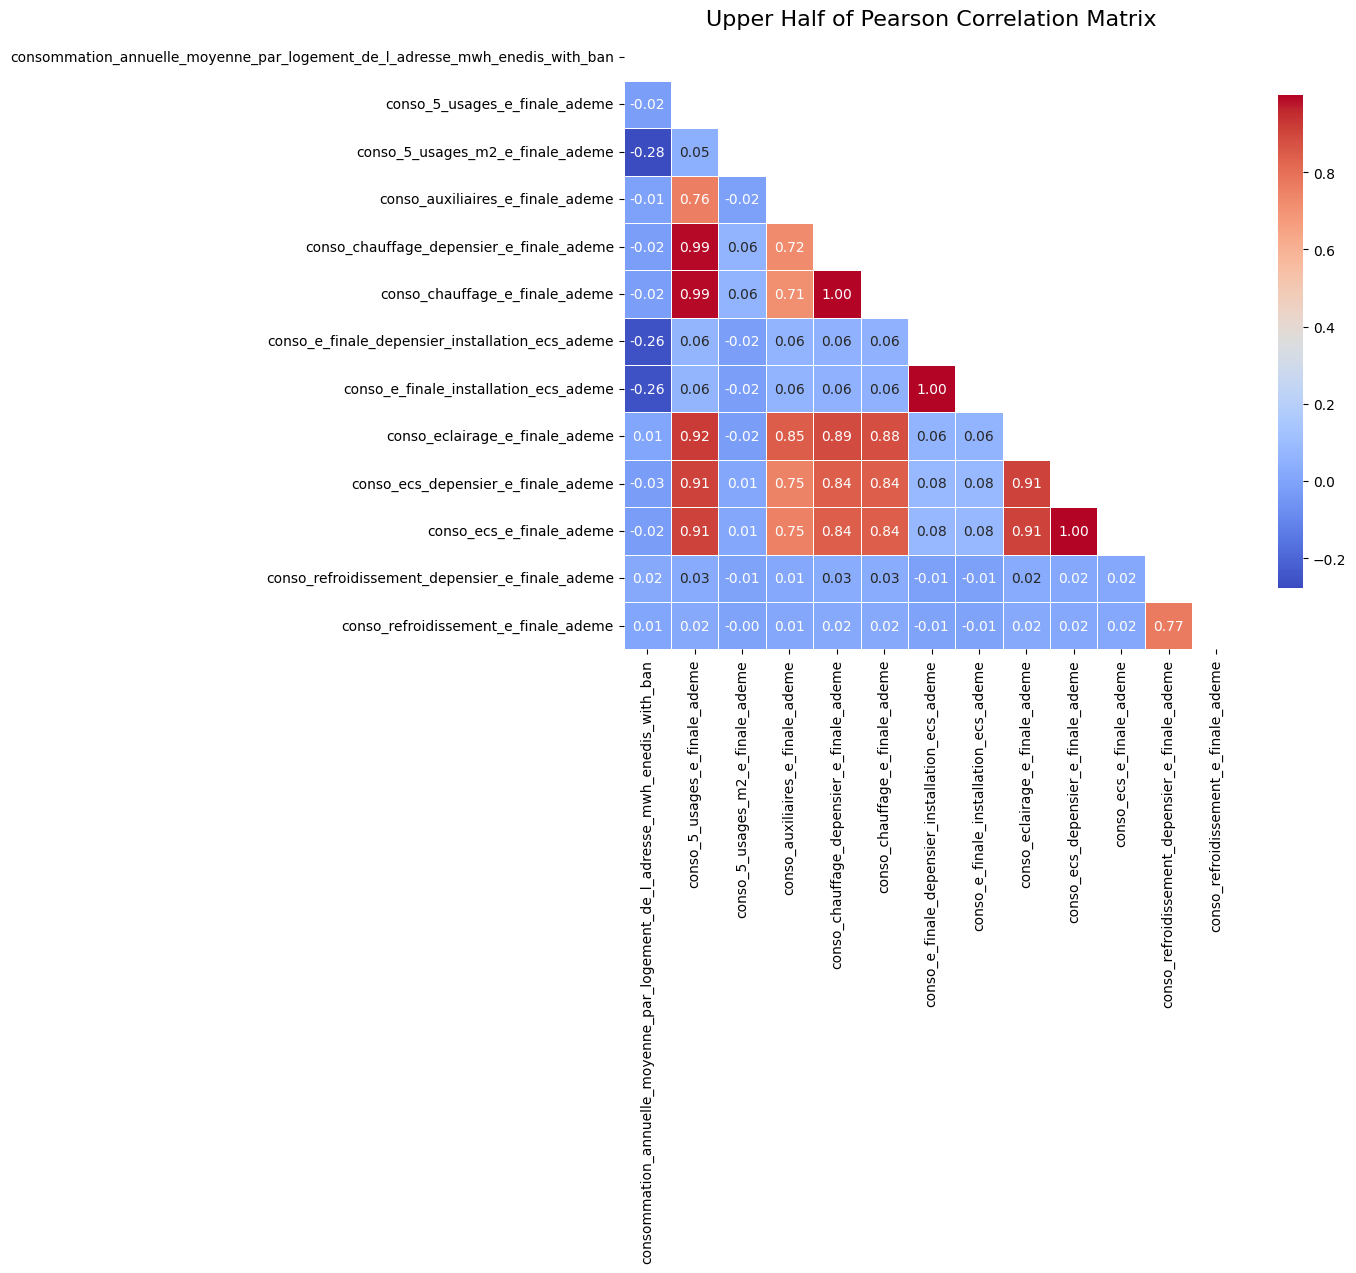

In [16]:
plot_upper_half_correlation_matrix(compute_pearson_correlation(df2))

In [17]:
_conso_fin_cols_ademe = list(filter(lambda c: ('finale' in c) and ('conso' in c) and ('ndeg' not in c) and ('depensier' not in c), _conso_fin_cols_ademe))
df3 = df2[_target + _conso_fin_cols_ademe]

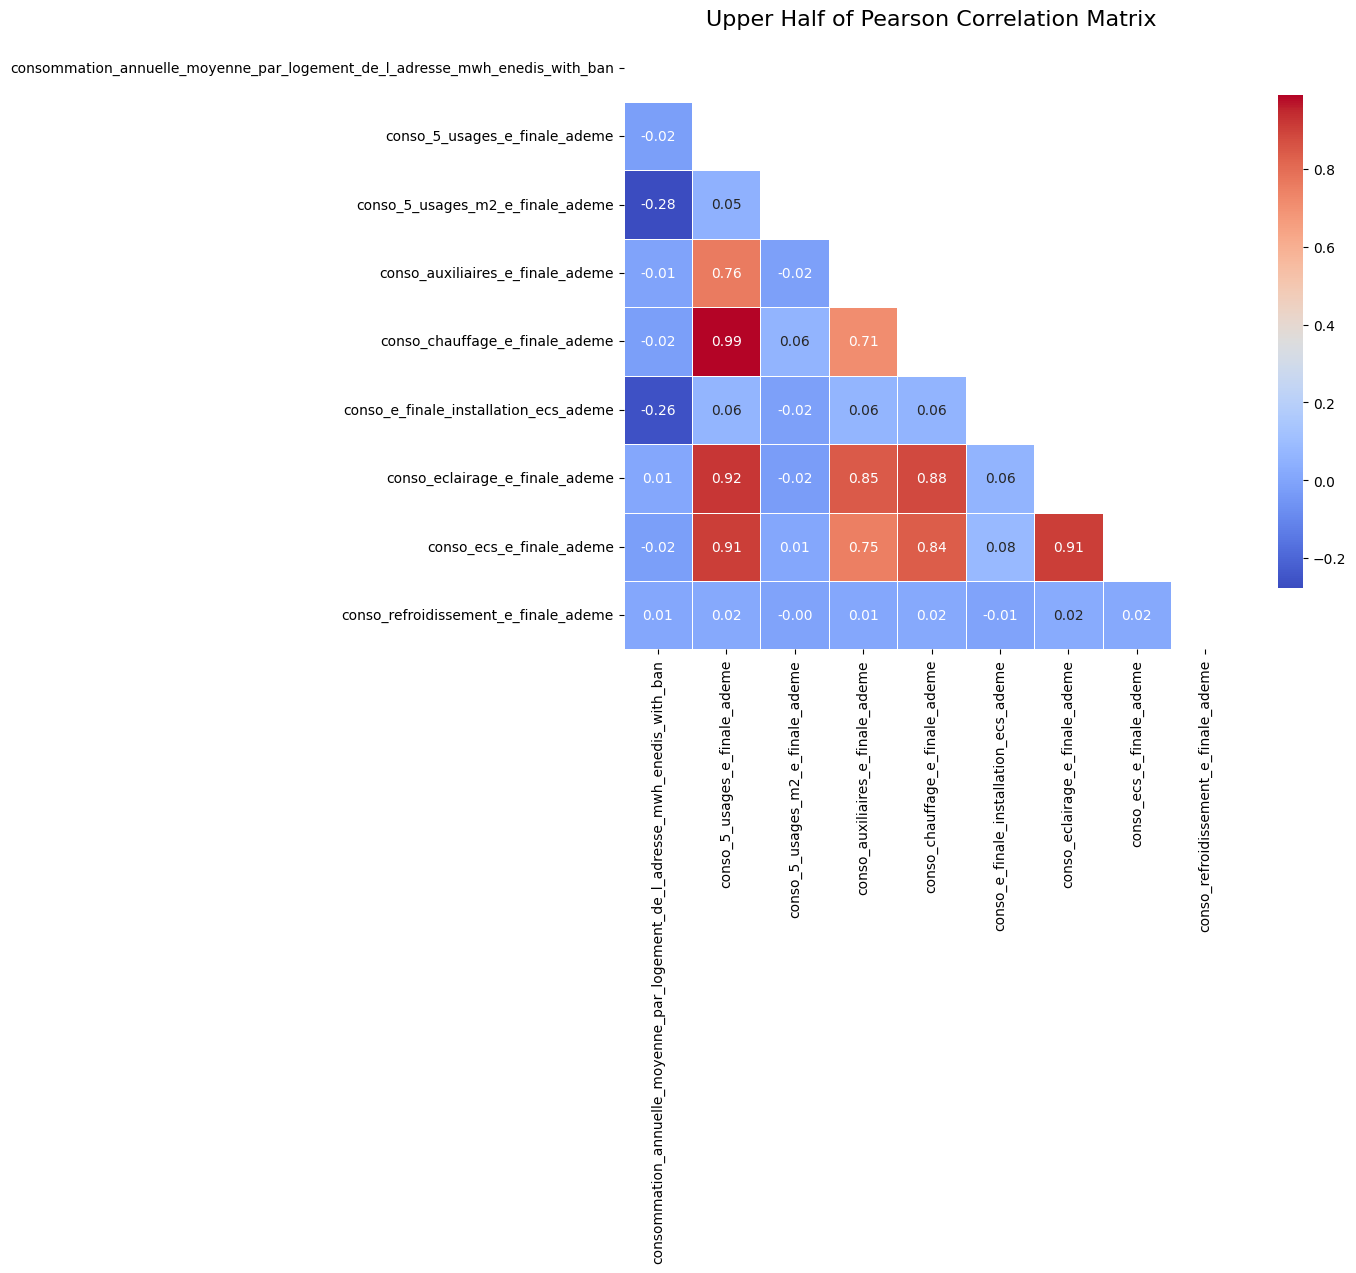

In [19]:
plot_upper_half_correlation_matrix(compute_pearson_correlation(df3))

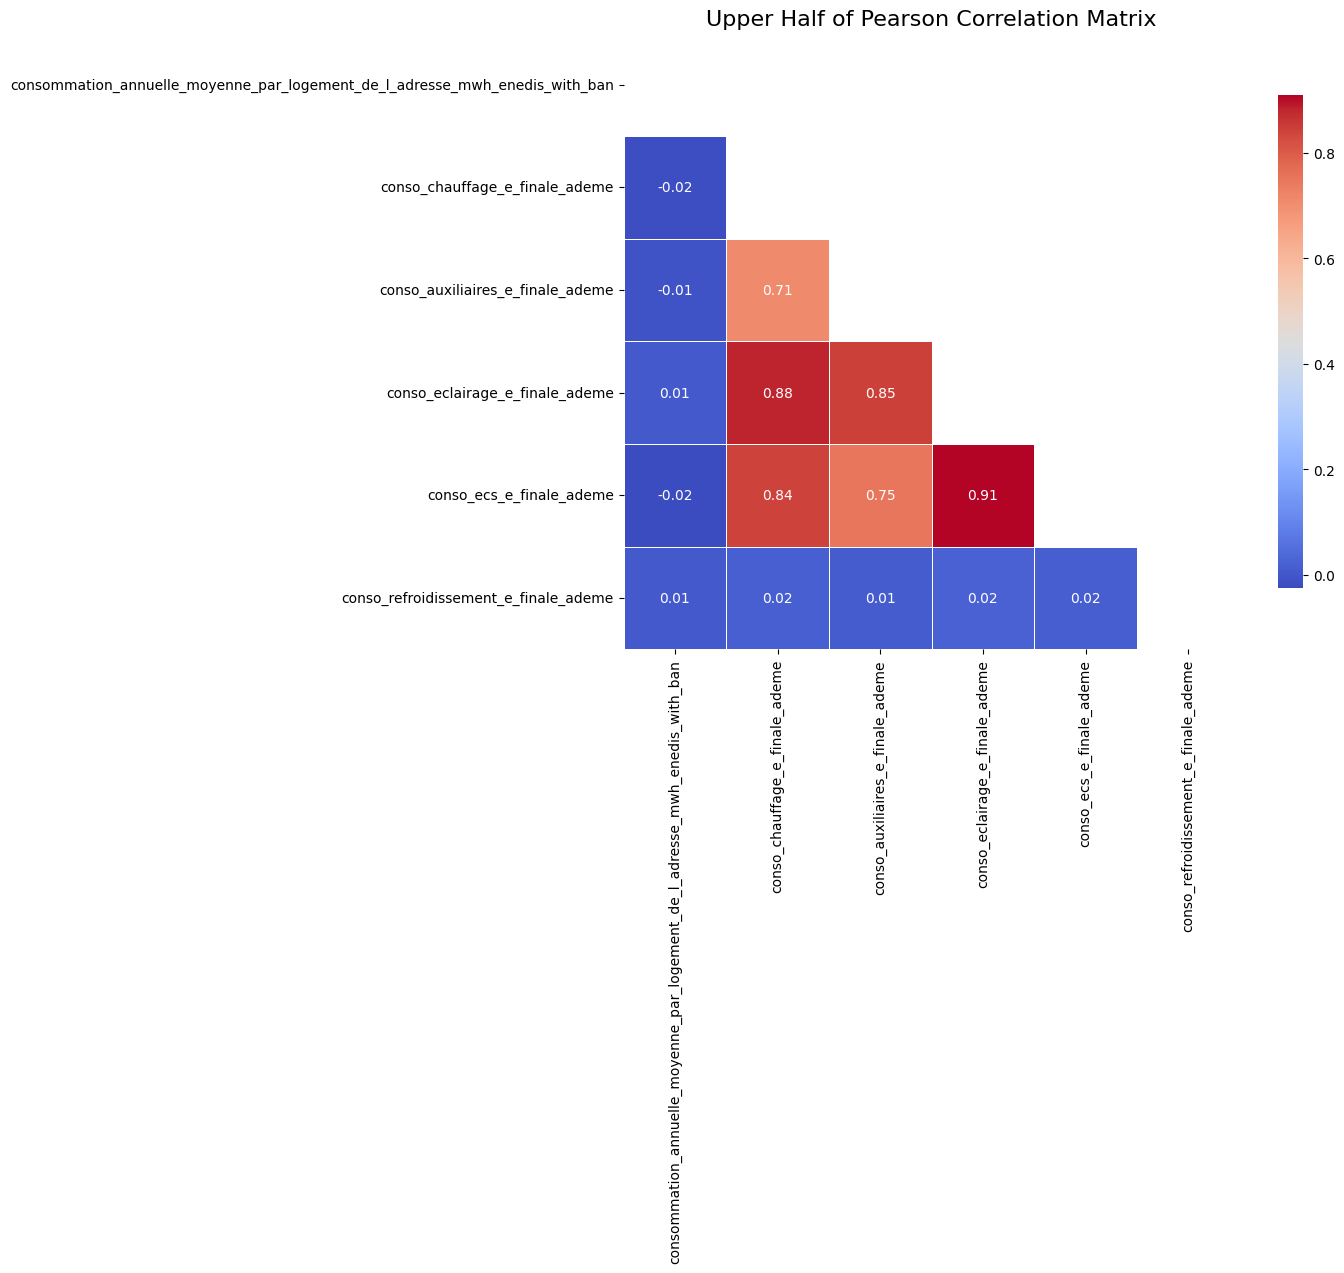

In [22]:
## garder juste la conso finale 5 usages qui décrit les habitudes (estimées) des occupants du logement
# enleve conso finale somme, moyenne au m2, 

_conso_cols_ademe_choix = [
    'conso_chauffage_e_finale_ademe',
    'conso_auxiliaires_e_finale_ademe',
    'conso_eclairage_e_finale_ademe',
    'conso_ecs_e_finale_ademe',
    'conso_refroidissement_e_finale_ademe'
]

df4 = df3[_target + _conso_cols_ademe_choix]
plot_upper_half_correlation_matrix(compute_pearson_correlation(df4))

In [24]:
# dataviz/entropie croisée entre conso 5 usages finale (somme) et conso estimée (target)
df3['consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'] = df3[_target] * 1_000

<Axes: xlabel='conso_5_usages_e_finale_ademe', ylabel='consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'>

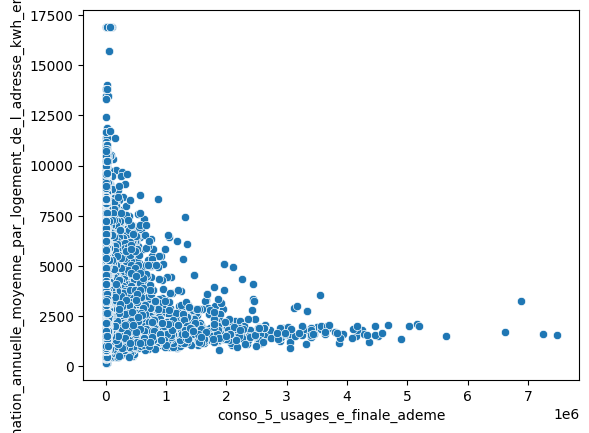

In [27]:
sns.scatterplot(df3, 
                x = 'conso_5_usages_e_finale_ademe',
                y='consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban')

# on s'attend à une évol en ligne alors qu'ici les logements dont on sous estiment la conso, consomment parfois plus,
# si on surestime la conso, il consomment parfois moins 
# effet restriction
# -- afficher avec le dpe en hue 

#### variables modele non contraint
*yc uniquement les variabls d'interet - ensuite on fera un modèle contraint en ajoutant les autres caractéristiues du logement*

In [40]:
variables = {
    'target': [],
    'features_nc': [],
    'features_c': []
}

_target = ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'] # a mettre en kwh (x 1_000)

variables.update({'target': _target})

In [43]:
_conso_cols_ademe_choix = [
    'conso_chauffage_e_finale_ademe',
    'conso_auxiliaires_e_finale_ademe',
    'conso_eclairage_e_finale_ademe',
    'conso_ecs_e_finale_ademe',
    'conso_refroidissement_e_finale_ademe'
]

_dpe_cols_choix = ['methode_application_dpe_ademe', 'version_dpe_ademe', 'etiquette_dpe_ademe']
_deperdition_cols = list(filter(lambda c: ('deperdition' in c.lower()), df.columns))

_features_nc = _conso_cols_ademe_choix + _dpe_cols_choix + _deperdition_cols

variables.update({'features_nc': _features_nc})


In [53]:
variables

{'target': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'],
 'features_nc': ['conso_chauffage_e_finale_ademe',
  'conso_auxiliaires_e_finale_ademe',
  'conso_eclairage_e_finale_ademe',
  'conso_ecs_e_finale_ademe',
  'conso_refroidissement_e_finale_ademe',
  'methode_application_dpe_ademe',
  'version_dpe_ademe',
  'etiquette_dpe_ademe',
  'deperditions_murs_ademe',
  'deperditions_planchers_bas_ademe',
  'deperditions_planchers_hauts_ademe',
  'deperditions_renouvellement_air_ademe',
  'deperditions_portes_ademe',
  'deperditions_baies_vitrees_ademe',
  'deperditions_ponts_thermiques_ademe',
  'deperditions_enveloppe_ademe'],
 'features_c': []}

In [ ]:
import pickle

with open('../ressources/data/3_cleaned/2025_01_15/variables_fereol.pkl', 'wb') as f:
    pickle.dump(variables, f)

In [3]:
import pickle
import pandas as pd

f = open('../ressources/data/3_cleaned/2025_01_15/variables_fereol.pkl', 'rb')
variables = pickle.load(f)

df = pd.read_parquet('../ressources/data/3_cleaned/2025_01_15/enedis_ban_ademe_extract_PARIS_2022.parquet')
df1 = df[variables.get('target') + variables.get('features_nc')]

In [4]:
import seaborn as sns, scipy
import matplotlib.pyplot as plt

In [63]:
df1.dtypes

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban           float64
conso_chauffage_e_finale_ademe                                                        float64
conso_auxiliaires_e_finale_ademe                                                      float64
conso_eclairage_e_finale_ademe                                                        float64
conso_ecs_e_finale_ademe                                                              float64
conso_refroidissement_e_finale_ademe                                                  float64
methode_application_dpe_ademe                                                  string[python]
version_dpe_ademe                                                                     float64
etiquette_dpe_ademe                                                            string[python]
deperditions_murs_ademe                                                               float64
deperditions_planchers_bas_ademe                            

In [130]:
df1['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'].describe()

count    464576.000000
mean          2.555306
std           1.309170
min           0.167000
25%           1.624000
50%           2.274000
75%           3.098000
max          16.924000
Name: consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban, dtype: float64

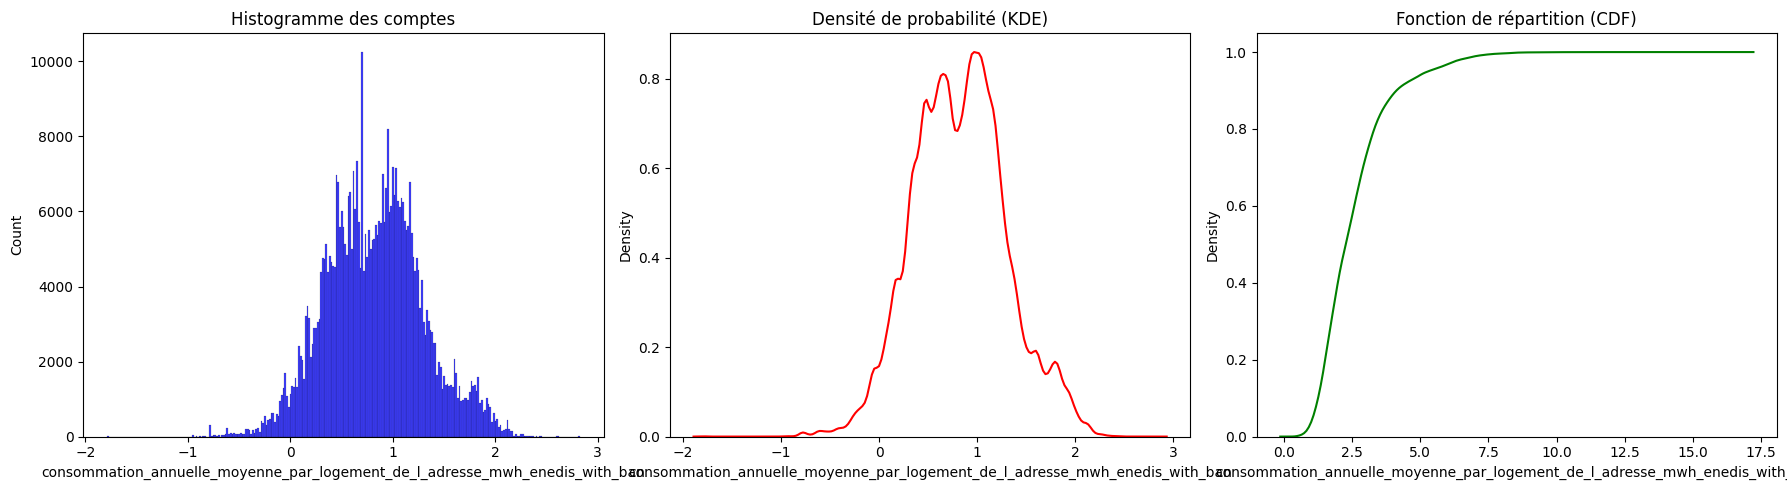

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(np.log(df1['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban']), stat='count', ax=axes[0], color='blue')
axes[0].set_title('Histogramme des comptes')

sns.kdeplot(np.log(df1['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban']), ax=axes[1], color='red')
axes[1].set_title('Densité de probabilité (KDE)')

sns.kdeplot(df1['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'], ax=axes[2], color='green', cumulative=True)
axes[2].set_title('Fonction de répartition (CDF)')

plt.tight_layout()
plt.show()

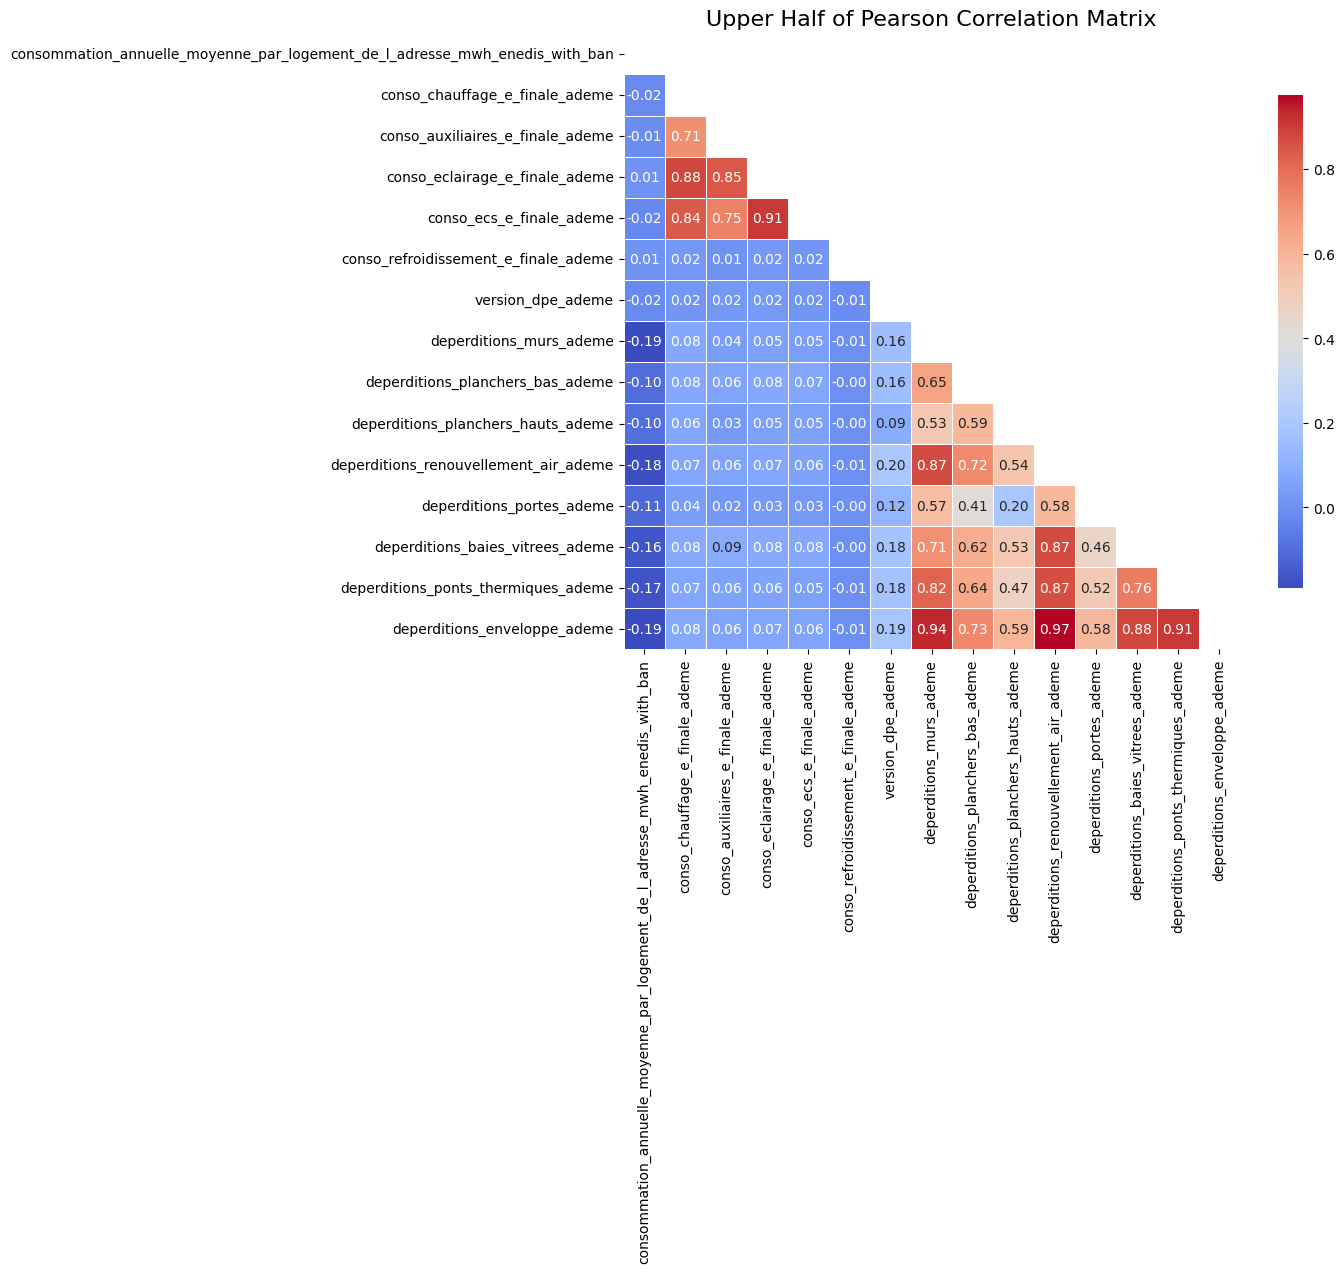

In [80]:
plot_upper_half_correlation_matrix(compute_pearson_correlation(df1.select_dtypes('float')))

In [81]:
import itertools

In [100]:
_dpe_cols

['date_etablissement_dpe_ademe',
 'ndegdpe_ademe',
 'methode_application_dpe_ademe',
 'date_reception_dpe_ademe',
 'date_fin_validite_dpe_ademe',
 'version_dpe_ademe',
 'etiquette_dpe_ademe',
 'ndeg_dpe_immeuble_associe_ademe']

In [133]:
len(df1)

464576

In [10]:
df2 = df1[_quant_cols]
df2.isna().sum()

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban       0
conso_chauffage_e_finale_ademe                                                    0
conso_auxiliaires_e_finale_ademe                                                  1
conso_eclairage_e_finale_ademe                                                    0
conso_ecs_e_finale_ademe                                                          0
conso_refroidissement_e_finale_ademe                                              0
version_dpe_ademe                                                                 0
deperditions_murs_ademe                                                        1059
deperditions_planchers_bas_ademe                                               1059
deperditions_planchers_hauts_ademe                                             1059
deperditions_renouvellement_air_ademe                                          1059
deperditions_portes_ademe                                                   

In [11]:
df2 = df1[_quant_cols].dropna()
df2.isna().sum()

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban    0
conso_chauffage_e_finale_ademe                                                 0
conso_auxiliaires_e_finale_ademe                                               0
conso_eclairage_e_finale_ademe                                                 0
conso_ecs_e_finale_ademe                                                       0
conso_refroidissement_e_finale_ademe                                           0
version_dpe_ademe                                                              0
deperditions_murs_ademe                                                        0
deperditions_planchers_bas_ademe                                               0
deperditions_planchers_hauts_ademe                                             0
deperditions_renouvellement_air_ademe                                          0
deperditions_portes_ademe                                                      0
deperditions_baies_vitrees_a

In [50]:
import numpy as np

_quant_cols = df1.select_dtypes(include='float').columns

df2 = df1[_quant_cols].dropna()

z_scores = np.abs(df2.apply(scipy.stats.zscore))
threshold = 2
df2 = df2[(z_scores < threshold).all(axis=1)]#.reset_index(drop=True)
len(df2)

365797

In [51]:
df2.min()

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban    0.167
conso_chauffage_e_finale_ademe                                                 0.000
conso_auxiliaires_e_finale_ademe                                               0.000
conso_eclairage_e_finale_ademe                                                 3.300
conso_ecs_e_finale_ademe                                                       0.000
conso_refroidissement_e_finale_ademe                                           0.000
version_dpe_ademe                                                              2.000
deperditions_murs_ademe                                                        0.000
deperditions_planchers_bas_ademe                                               0.000
deperditions_planchers_hauts_ademe                                             0.000
deperditions_renouvellement_air_ademe                                          0.400
deperditions_portes_ademe                                        

In [54]:
df2.mean()/df2.std() # la ùoyenne se compense avec le std du coup les observtaions dont la valeur egale à 0 ont un zscore < 2

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban     2.519871
conso_chauffage_e_finale_ademe                                                  0.919396
conso_auxiliaires_e_finale_ademe                                                0.784831
conso_eclairage_e_finale_ademe                                                  1.113522
conso_ecs_e_finale_ademe                                                        1.211687
conso_refroidissement_e_finale_ademe                                            0.069253
version_dpe_ademe                                                              21.779353
deperditions_murs_ademe                                                         0.411777
deperditions_planchers_bas_ademe                                                0.457435
deperditions_planchers_hauts_ademe                                              0.391513
deperditions_renouvellement_air_ademe                                           0.455152
deperditions_portes_a

In [56]:
df2.describe()

,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,conso_chauffage_e_finale_ademe,conso_auxiliaires_e_finale_ademe,conso_eclairage_e_finale_ademe,conso_ecs_e_finale_ademe,conso_refroidissement_e_finale_ademe,version_dpe_ademe,deperditions_murs_ademe,deperditions_planchers_bas_ademe,deperditions_planchers_hauts_ademe,deperditions_renouvellement_air_ademe,deperditions_portes_ademe,deperditions_baies_vitrees_ademe,deperditions_ponts_thermiques_ademe,deperditions_enveloppe_ademe
count,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000,365797.000000
mean,2.404451,7384.120964,216.916931,92.746781,2198.334907,0.232636,2.264888,534.401397,35.960200,60.983429,648.585289,9.616805,348.255785,279.377623,1916.047060
std,0.954196,8031.491491,276.386843,83.291415,1814.275685,3.359234,0.103992,1297.793109,78.612672,155.763418,1424.987160,27.732641,791.737634,666.646831,4072.536083
min,0.167000,0.000000,0.000000,3.300000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,4.100000
25%,1.648000,2810.300000,0.000000,50.600000,1358.600000,0.000000,2.200000,24.600000,0.000000,0.000000,23.200000,0.000000,11.500000,5.300000,79.500000
50%,2.327000,5147.500000,177.800000,77.500000,1708.300000,0.000000,2.300000,54.500000,0.000000,0.000000,41.700000,1.500000,23.700000,11.800000,141.900000
75%,3.015000,9373.800000,299.900000,117.000000,2364.500000,0.000000,2.300000,164.600000,21.200000,43.700000,147.400000,3.900000,101.200000,45.800000,511.000000
max,5.173000,141316.500000,6594.700000,1886.200000,41722.200000,94.800000,2.400000,8996.300000,490.200000,1375.000000,8326.800000,235.200000,5264.000000,4537.400000,23361.000000


In [82]:
import numpy as np

_quant_cols = df1.select_dtypes(include='float').columns

df2 = df1[_quant_cols].dropna()

z_scores = np.abs(df2.apply(scipy.stats.zscore))
threshold = 2
df2 = df2[(z_scores < threshold).all(axis=1)] #.reset_index(drop=True)
_zero_cols = [
    'conso_refroidissement_e_finale_ademe', 
    'conso_auxiliaires_e_finale_ademe',
    'deperditions_planchers_hauts_ademe', 
    'deperditions_planchers_bas_ademe', 
    'deperditions_planchers_hauts_ademe',
    'deperditions_portes_ademe'
    ] # colonnes ayant + de 50% de 0
df2.drop(_zero_cols, axis=1, inplace=True)
df2 = df2[(df2 != 0).all(axis=1)]

# en suite logger les variables qui couvrent plusieurs ordres de grandeur et/ou dont la distribution est assymetrique 
_log_cols = [
    c for c in df2.columns if c not in ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban', 'version_dpe_ademe']
]

for c in _log_cols:
    df2[c] = np.log(df2[c])


In [75]:
df2.std()/df2.mean()

consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban    0.396845
conso_chauffage_e_finale_ademe                                                 1.087673
conso_eclairage_e_finale_ademe                                                 0.898047
conso_ecs_e_finale_ademe                                                       0.825297
version_dpe_ademe                                                              0.045915
deperditions_murs_ademe                                                        2.428497
deperditions_renouvellement_air_ademe                                          2.197068
deperditions_baies_vitrees_ademe                                               2.273434
deperditions_ponts_thermiques_ademe                                            2.386182
deperditions_enveloppe_ademe                                                   2.125486
dtype: float64

In [84]:
np.exp(-0.356675)

np.float64(0.6999999607571138)

In [83]:
df2.describe()

,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,conso_chauffage_e_finale_ademe,conso_eclairage_e_finale_ademe,conso_ecs_e_finale_ademe,version_dpe_ademe,deperditions_murs_ademe,deperditions_renouvellement_air_ademe,deperditions_baies_vitrees_ademe,deperditions_ponts_thermiques_ademe,deperditions_enveloppe_ademe
count,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000
mean,2.373100,8.597352,4.361329,7.564432,2.266414,4.555009,4.566990,3.941103,3.393034,5.781144
std,0.955723,0.862262,0.627752,0.536917,0.104039,1.831668,1.938973,1.956120,2.137571,1.864905
min,0.167000,-0.356675,1.193922,-2.302585,2.000000,-2.302585,-0.693147,-2.302585,-2.302585,1.410987
25%,1.613000,8.043952,3.972177,7.246439,2.200000,3.377588,3.238678,2.557227,1.931521,4.486387
50%,2.272000,8.615590,4.398146,7.470566,2.300000,4.109233,3.817712,3.277145,2.631889,5.046646
75%,2.985000,9.190268,4.781641,7.800204,2.300000,5.463832,6.153371,5.253843,4.960745,7.258905
max,5.173000,11.858757,7.542320,10.638789,2.400000,9.104569,9.027235,8.568646,8.420109,10.058823


In [98]:
df3 = df1.loc[df2.index, list(df2.columns)+['methode_application_dpe_ademe', 'etiquette_dpe_ademe']]

_log_cols = [
    c for c in df2.select_dtypes(include='float').columns if c not in ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban', 'version_dpe_ademe']
]

for c in _log_cols:
    df3[c] = np.log(df3[c])


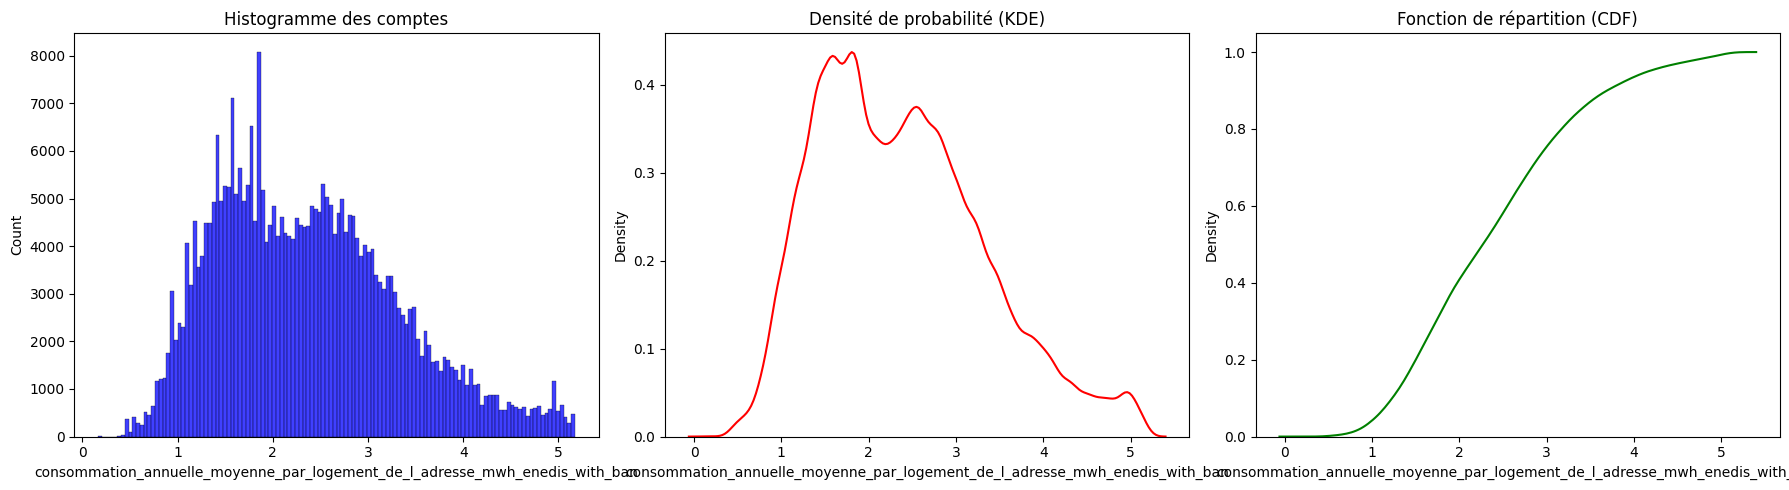

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df3['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'], stat='count', ax=axes[0], color='blue')
axes[0].set_title('Histogramme des comptes')

sns.kdeplot(df3['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'], ax=axes[1], color='red')
axes[1].set_title('Densité de probabilité (KDE)')

sns.kdeplot(df3['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'], ax=axes[2], color='green', cumulative=True)
axes[2].set_title('Fonction de répartition (CDF)')

plt.tight_layout()
plt.show()

In [100]:
df3.describe()

,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,conso_chauffage_e_finale_ademe,conso_eclairage_e_finale_ademe,conso_ecs_e_finale_ademe,version_dpe_ademe,deperditions_murs_ademe,deperditions_renouvellement_air_ademe,deperditions_baies_vitrees_ademe,deperditions_ponts_thermiques_ademe,deperditions_enveloppe_ademe
count,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000,329340.000000
mean,2.373100,8.597352,4.361329,7.564432,2.266414,4.555009,4.566990,3.941103,3.393034,5.781144
std,0.955723,0.862262,0.627752,0.536917,0.104039,1.831668,1.938973,1.956120,2.137571,1.864905
min,0.167000,-0.356675,1.193922,-2.302585,2.000000,-2.302585,-0.693147,-2.302585,-2.302585,1.410987
25%,1.613000,8.043952,3.972177,7.246439,2.200000,3.377588,3.238678,2.557227,1.931521,4.486387
50%,2.272000,8.615590,4.398146,7.470566,2.300000,4.109233,3.817712,3.277145,2.631889,5.046646
75%,2.985000,9.190268,4.781641,7.800204,2.300000,5.463832,6.153371,5.253843,4.960745,7.258905
max,5.173000,11.858757,7.542320,10.638789,2.400000,9.104569,9.027235,8.568646,8.420109,10.058823


C:\Users\gbeno\AppData\Local\Temp\ipykernel_21788\2741436297.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\gbeno\Documents\m2_deng\ydays\CHALLENGE-DPE-OPENDATA-UNIV\venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


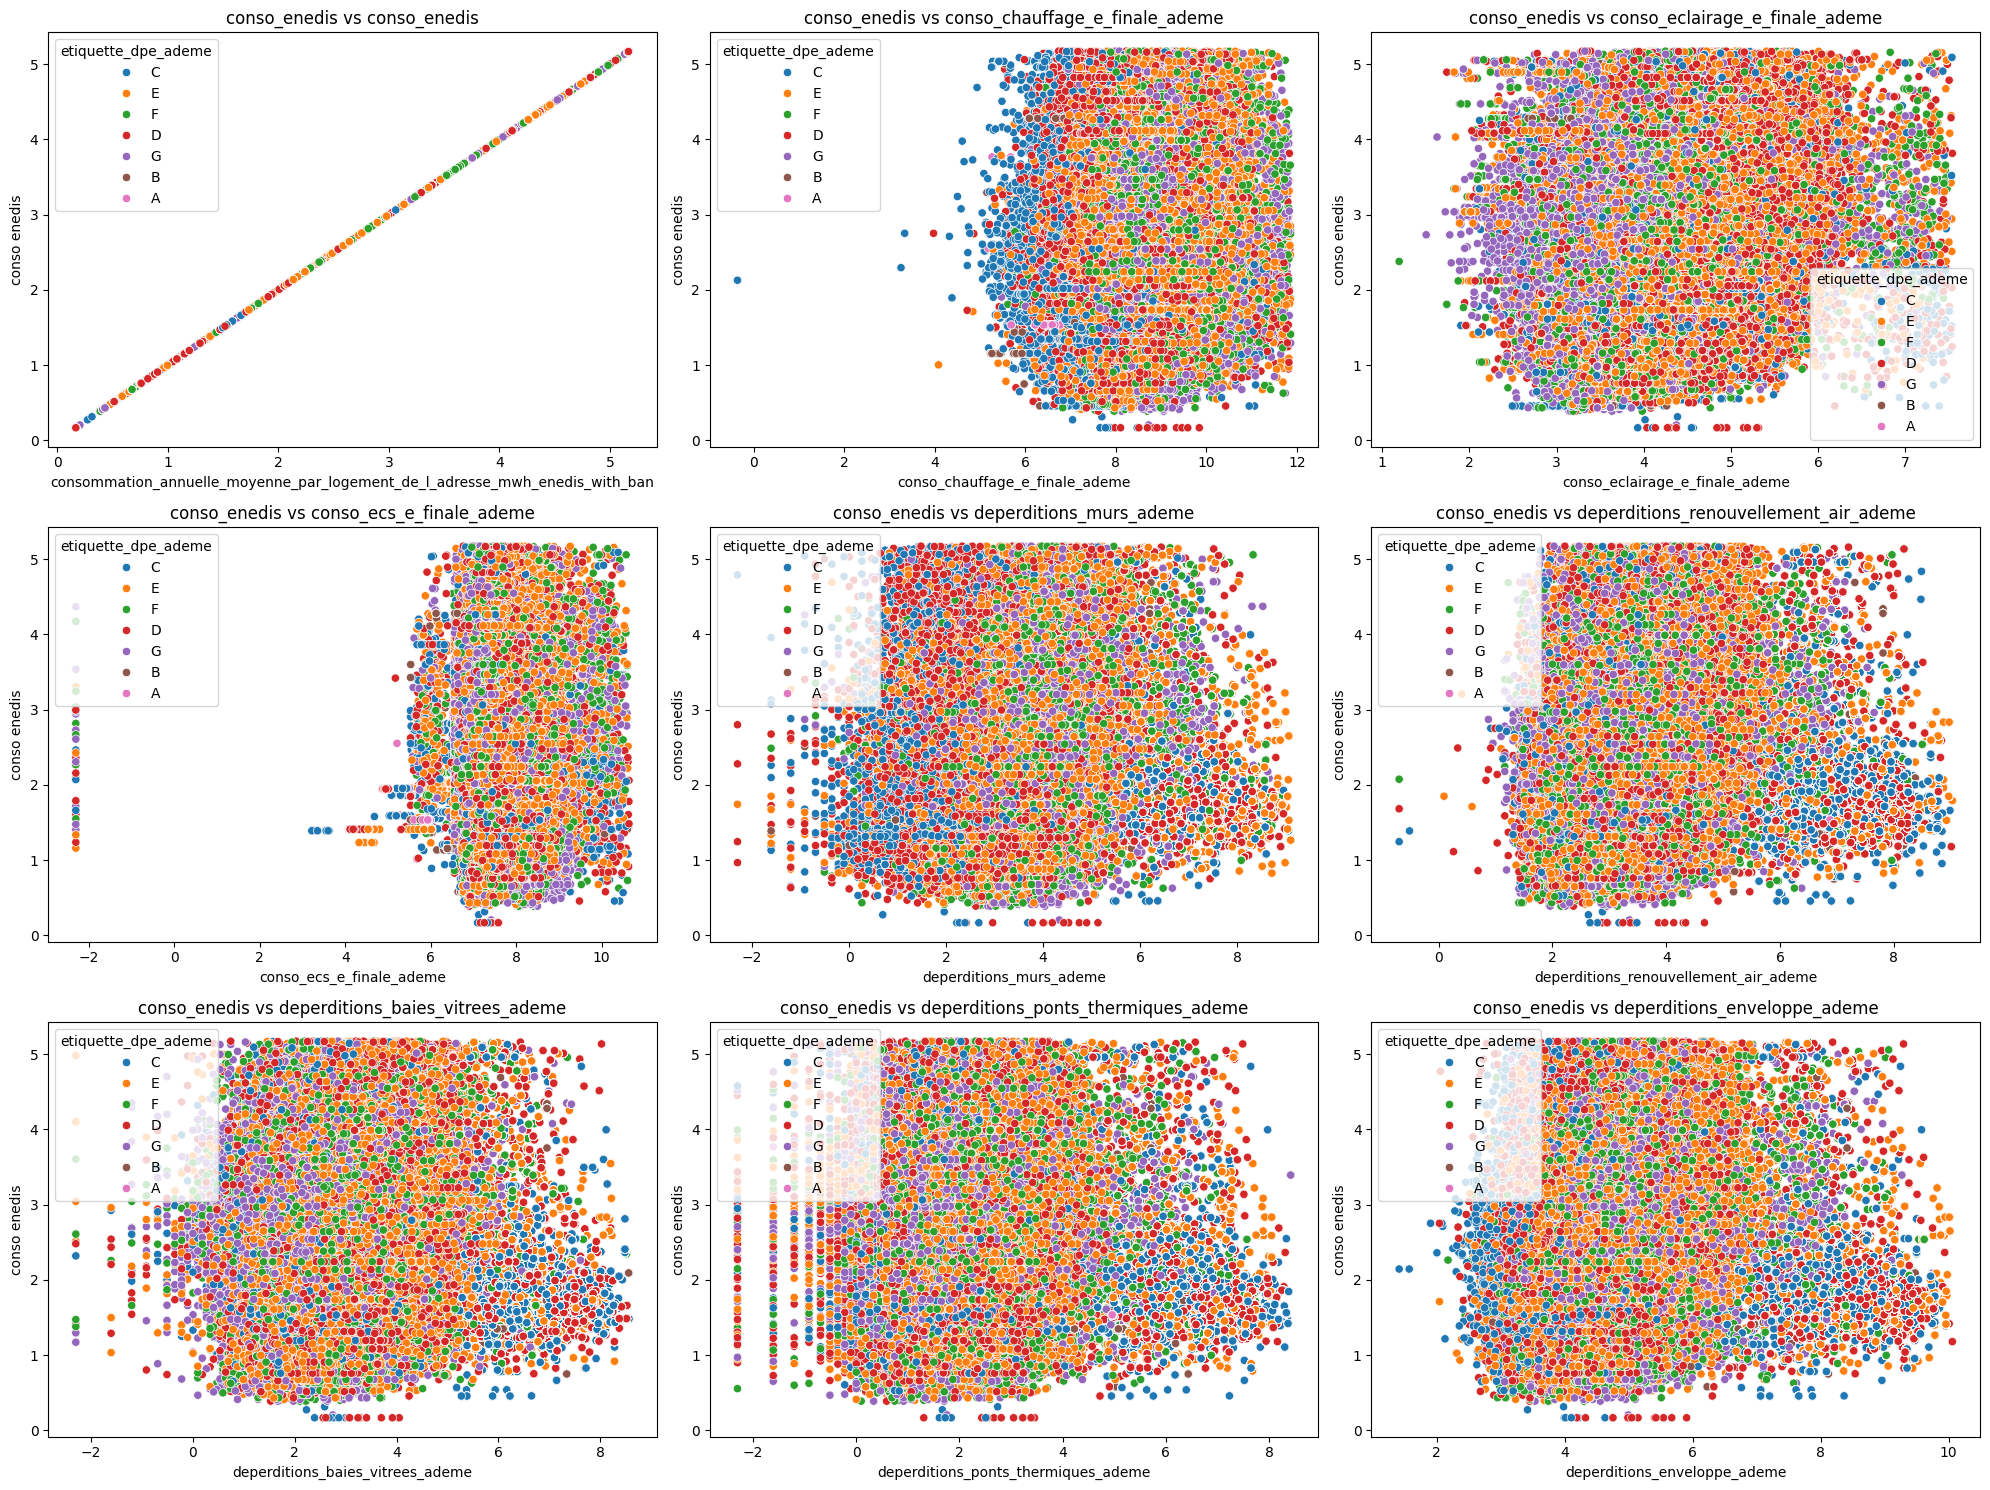

In [106]:
import itertools

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

_quant_cols = df3.select_dtypes(include='float').columns
_skip_cols = ['version_dpe_ademe']
_quant_cols = list(filter(lambda x: x not in _skip_cols, _quant_cols))  
_target = 'consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'

for i,c in enumerate(itertools.product(_quant_cols, _quant_cols)):
    row, col = divmod(i, 3)
    if c[0] == _target:
        sns.scatterplot(df3, y=_target, x=c[1], hue='etiquette_dpe_ademe', ax=axes[row, col])
        axes[row, col].set_ylabel("conso enedis")
        axes[row, col].set_xlabel(c[1])
        if c[1] == _target:
            axes[row, col].set_title(f'conso_enedis vs conso_enedis')
        else:
            axes[row, col].set_title(f'conso_enedis vs {c[1]}')

plt.tight_layout()
plt.show()

In [126]:
import pandas as pd

def stratified_sampling(df, x, sample_size, random_state=None):
    """
    Tire un échantillon stratifié d'un DataFrame en fonction d'une variable qualitative.
    
    Paramètres :
    - df : DataFrame pandas
    - x : Nom de la colonne qualitative à utiliser pour la stratification
    - sample_size : Taille totale de l'échantillon souhaité
    - random_state : (optionnel) Seed pour la reproductibilité

    Retour :
    - Un DataFrame échantillonné stratifié selon `x`
    """
    # Vérifier que la colonne existe et est qualitative
    if x not in df.columns:
        raise ValueError(f"La colonne '{x}' n'existe pas dans le DataFrame.")

    # Taille de l'échantillon par catégorie
    stratified_sample = df.groupby(x, group_keys=False).apply(
        lambda group: group.sample(
            n=max(1, round(sample_size * len(group) / len(df))),  # Nombre proportionnel
            random_state=random_state
        )
    )

    return stratified_sample.sample(n=sample_size, random_state=random_state)  # Ajustement final

df3_sub = stratified_sampling(df3.copy(), x='etiquette_dpe_ademe', sample_size=500).reset_index(drop=True)

C:\Users\gbeno\AppData\Local\Temp\ipykernel_21788\579617842.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby(x, group_keys=False).apply(


In [127]:
df3_sub.etiquette_dpe_ademe.value_counts('freq') * 100

etiquette_dpe_ademe
E    29.0
D    26.4
F    15.8
C    14.2
G    13.4
B     1.0
A     0.2
Name: proportion, dtype: Float64

In [112]:
df3.etiquette_dpe_ademe.value_counts('freq') * 100

etiquette_dpe_ademe
E    29.095767
D      26.4608
F    15.867796
C    14.260339
G    13.338192
B     0.964657
A     0.012449
Name: proportion, dtype: Float64

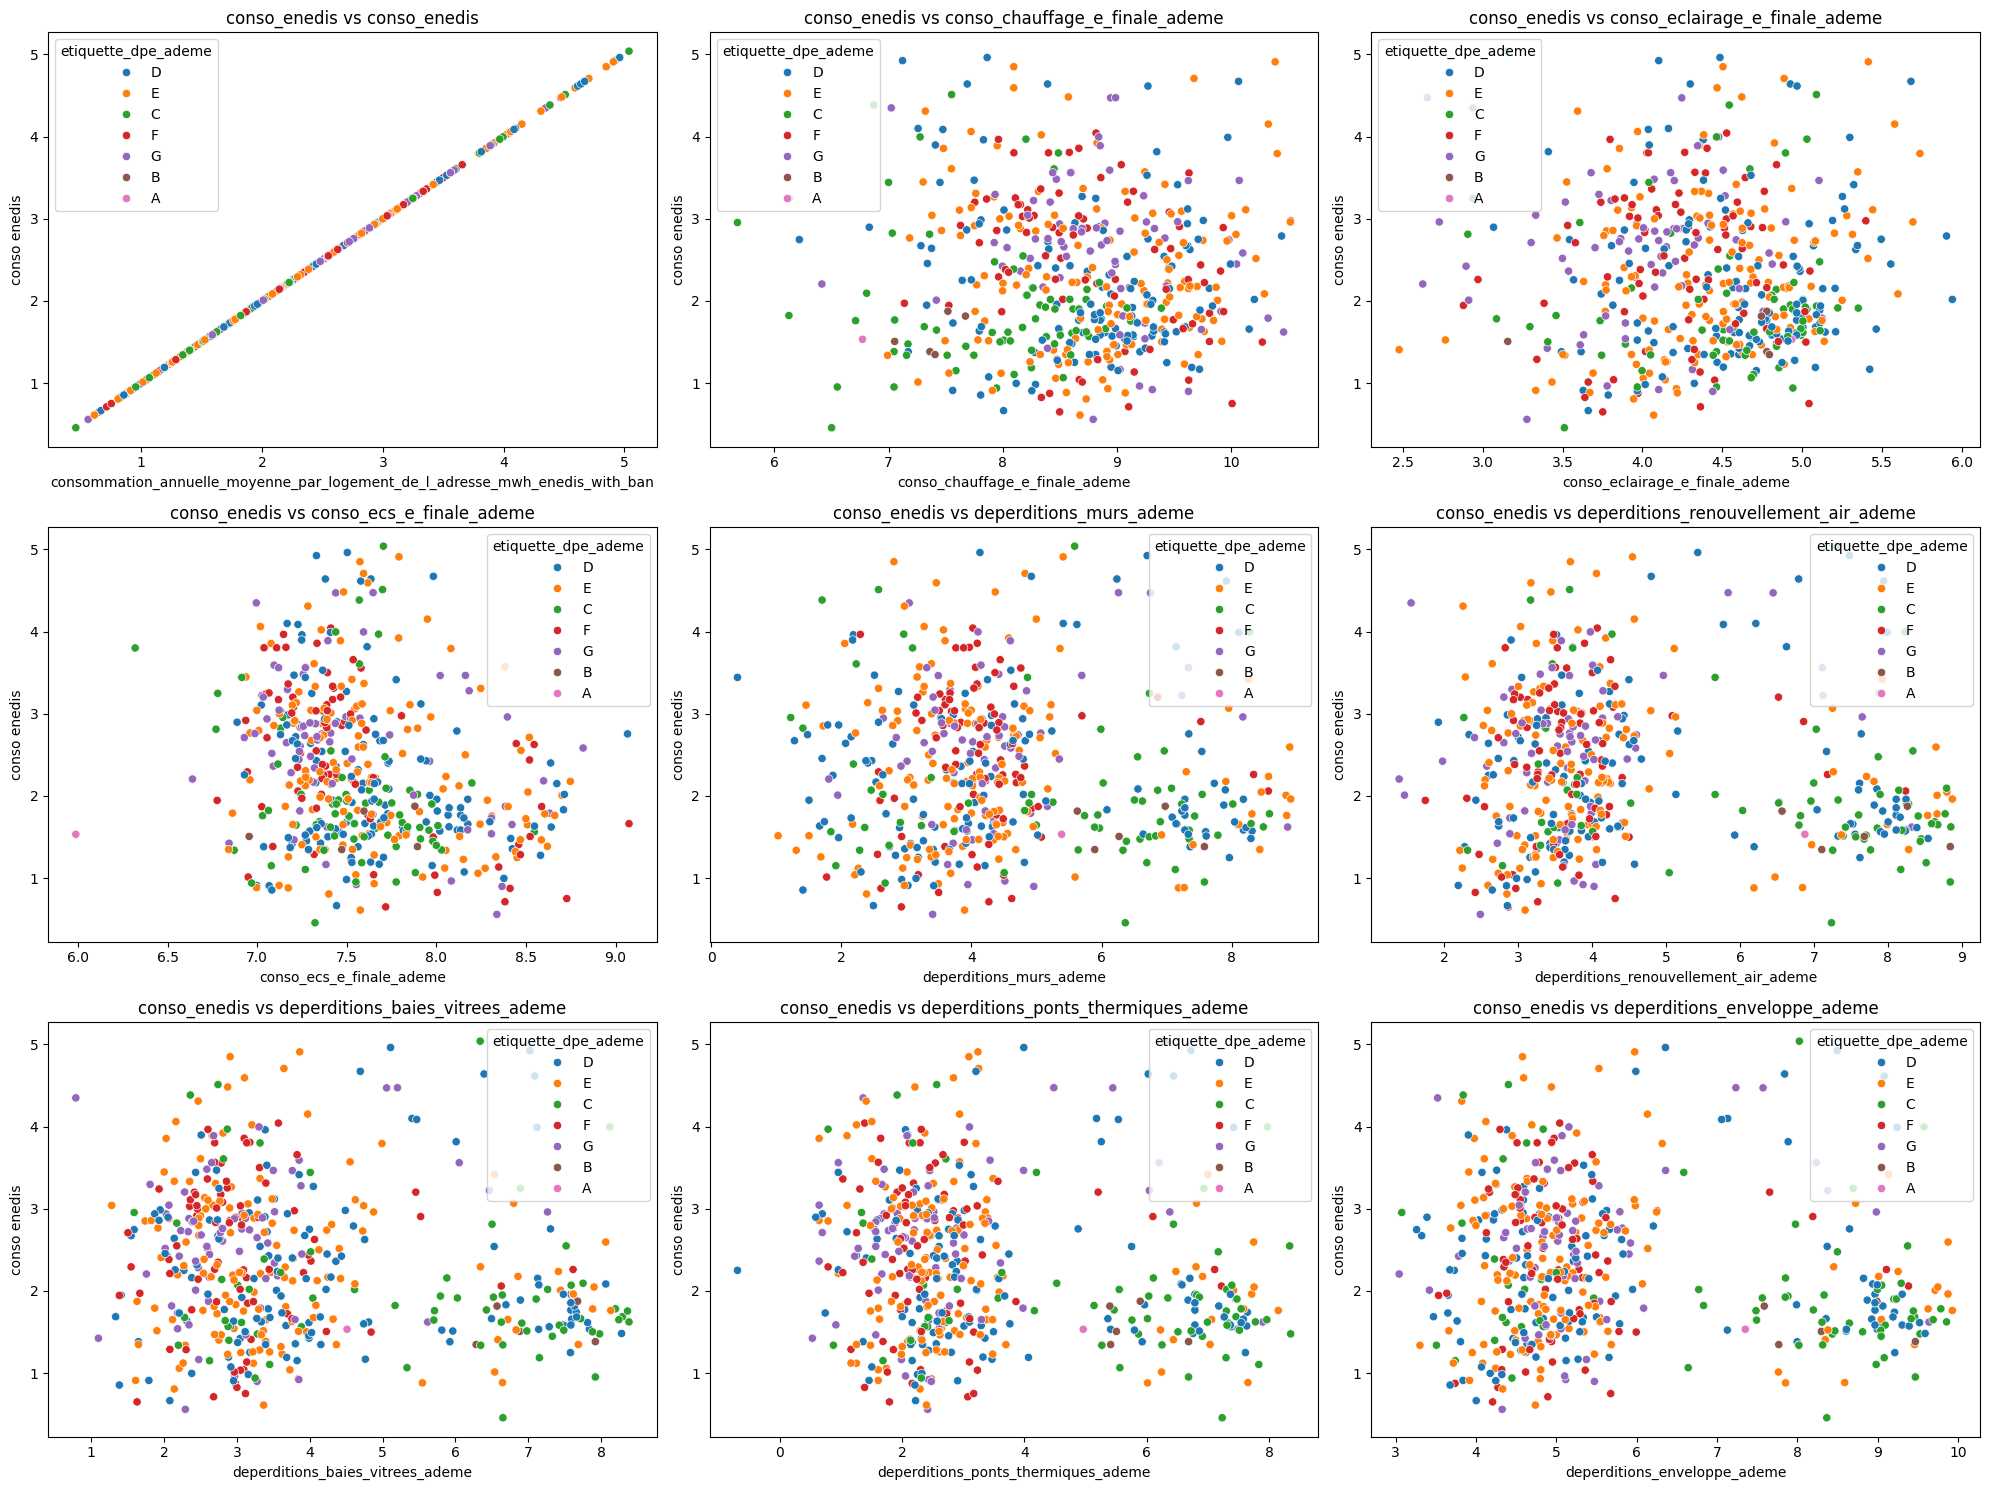

In [128]:
import itertools

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

_quant_cols = df3_sub.select_dtypes(include='float').columns
_skip_cols = ['version_dpe_ademe']
_quant_cols = list(filter(lambda x: x not in _skip_cols, _quant_cols))  
_target = 'consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'

for i,c in enumerate(itertools.product(_quant_cols, _quant_cols)):
    row, col = divmod(i, 3)
    if c[0] == _target:
        sns.scatterplot(df3_sub, y=_target, x=c[1], hue='etiquette_dpe_ademe', ax=axes[row, col])
        axes[row, col].set_ylabel("conso enedis")
        axes[row, col].set_xlabel(c[1])
        if c[1] == _target:
            axes[row, col].set_title(f'conso_enedis vs conso_enedis')
        else:
            axes[row, col].set_title(f'conso_enedis vs {c[1]}')

plt.tight_layout()
plt.show()

In [118]:
df3_sub.etiquette_dpe_ademe.value_counts()

etiquette_dpe_ademe
E    145
D    132
F     79
C     71
G     67
B      5
A      1
Name: count, dtype: Int64

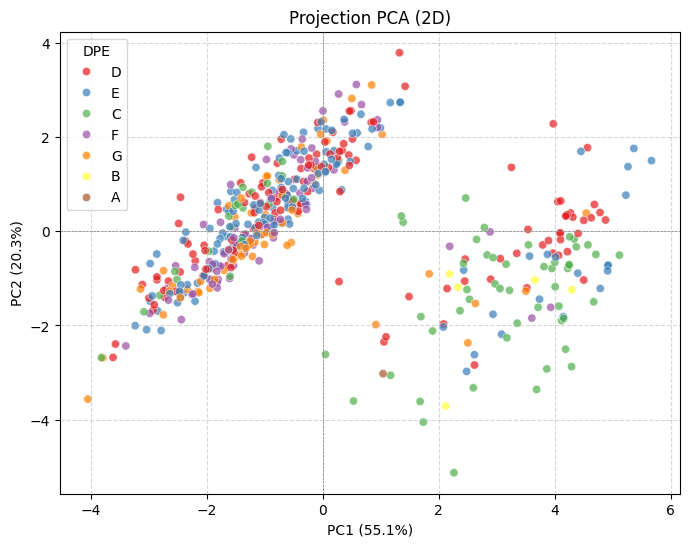

In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sélectionner uniquement les colonnes numériques
features = _quant_cols

# Standardiser les données avant la PCA
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df3_sub[features])

# Appliquer la PCA
pca = PCA(n_components=2)  # On garde les 2 premières composantes
principal_components = pca.fit_transform(df_scaled)

# Créer un DataFrame avec les nouvelles composantes
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca["DPE"] = df3_sub["etiquette_dpe_ademe"]  # Ajouter la variable cible si elle existe

# Tracer le scatter plot des deux premières composantes principales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue='DPE', palette="Set1", alpha=0.7)

# Ajouter des titres et labels
plt.title("Projection PCA (2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


In [125]:
df3_sub

,consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban,conso_chauffage_e_finale_ademe,conso_eclairage_e_finale_ademe,conso_ecs_e_finale_ademe,version_dpe_ademe,deperditions_murs_ademe,deperditions_renouvellement_air_ademe,deperditions_baies_vitrees_ademe,deperditions_ponts_thermiques_ademe,deperditions_enveloppe_ademe,methode_application_dpe_ademe,etiquette_dpe_ademe
119573,1.732,8.245542,4.219508,7.059102,2.1,3.182212,3.044522,2.681022,2.985682,4.374498,dpe appartement individuel,C
430108,2.441,9.013096,4.369448,7.401903,2.3,4.079231,3.563883,2.468100,1.686399,4.714025,dpe appartement individuel,E
155756,1.286,9.800679,5.013963,7.880691,2.3,4.063885,4.178992,4.293195,3.277145,5.408068,dpe appartement individuel,E
182465,2.403,9.011096,4.058717,7.380692,2.3,4.671894,3.781914,3.152736,2.564949,5.240688,dpe appartement individuel,G
254149,4.736,7.321387,4.876723,7.468228,2.3,6.958924,8.259484,6.921066,6.300235,8.894396,dpe appartement généré à partir des données DP...,C
...,...,...,...,...,...,...,...,...,...,...,...,...
361773,1.838,8.578476,4.971201,7.749193,2.4,6.546211,7.410408,6.443972,6.543912,8.289414,dpe appartement généré à partir des données DP...,C
384862,1.942,6.278897,3.407842,6.932448,2.2,5.506550,6.779012,5.751302,6.125558,7.657519,dpe appartement généré à partir des données DP...,C
233518,0.782,7.448974,4.077537,7.551660,2.3,6.327222,7.358321,6.372125,5.690697,8.089912,dpe appartement généré à partir des données DP...,C
425857,3.120,8.464446,4.092677,7.217517,2.4,6.829253,6.809370,6.068888,5.880254,7.912679,dpe appartement généré à partir des données DP...,G


In [102]:
_qual_cols = [c for c in df1.columns if c not in _quant_cols]
_qual_cols

['methode_application_dpe_ademe', 'version_dpe_ademe', 'etiquette_dpe_ademe']

In [103]:
for _ in _qual_cols:
    print(df1[_].value_counts(dropna=False))

methode_application_dpe_ademe
dpe appartement individuel                                                    304798
dpe appartement généré à partir des données DPE immeuble                      151927
dpe immeuble collectif                                                          6235
dpe maison individuelle                                                         1565
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : appartement        50
dpe issu d'une étude thermique réglementaire RT2012 bâtiment : immeuble            1
Name: count, dtype: Int64
version_dpe_ademe
2.3    161803
2.4    118846
2.2    109977
2.1     43922
2.0     11120
1.1     10025
1.0      8883
Name: count, dtype: int64
etiquette_dpe_ademe
D    133890
E    130053
C     73601
F     66814
G     56236
B      3901
A        81
Name: count, dtype: Int64


Text(0, 0.5, 'conso_enedis')

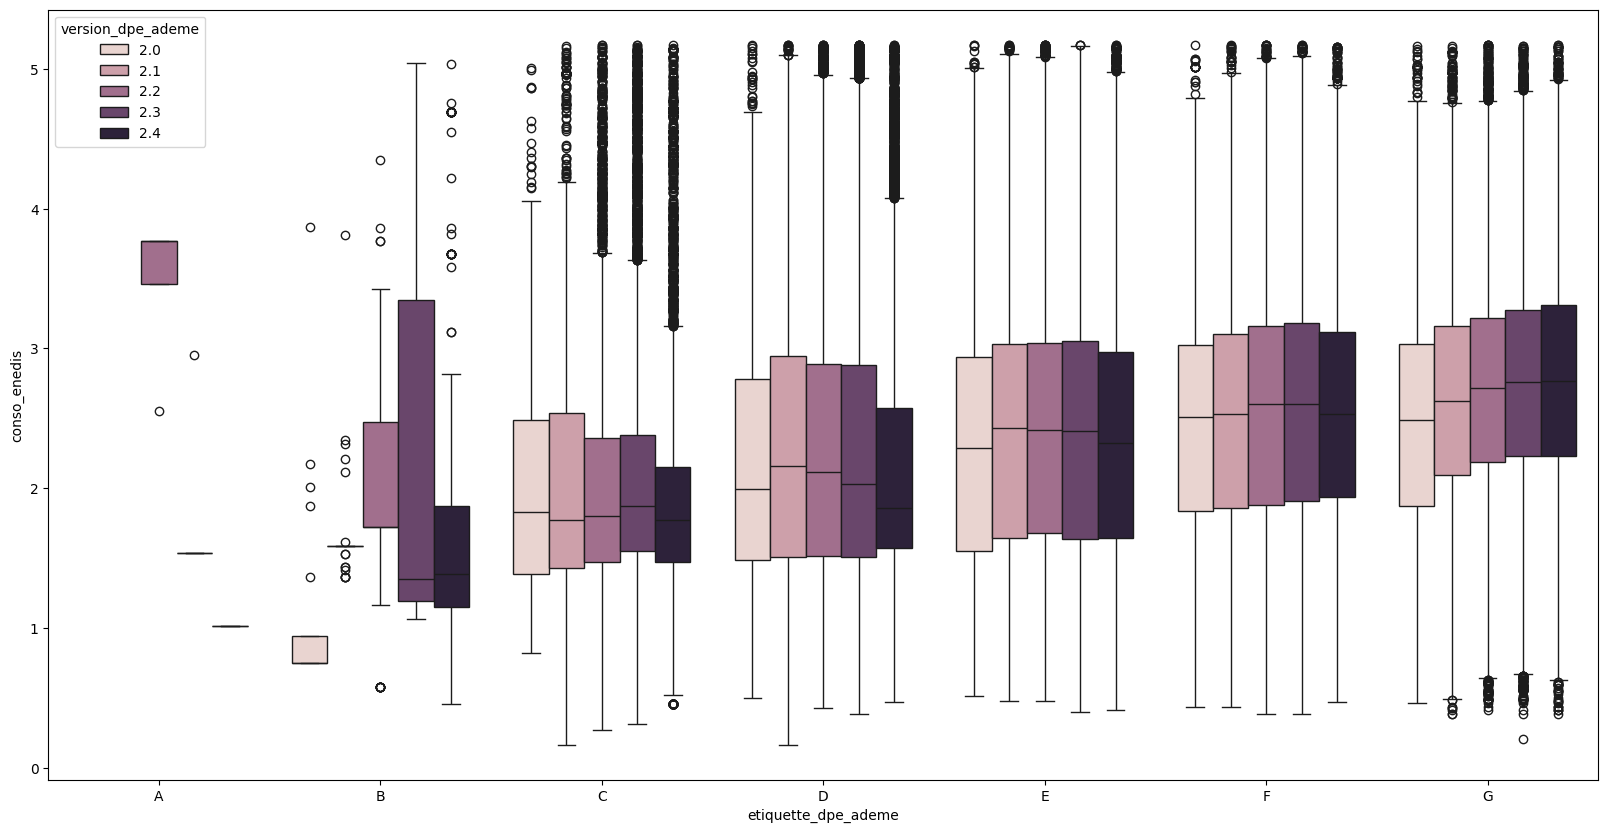

In [132]:
fig, axs = plt.subplots(figsize=(20, 10))

sns.boxplot(df3, x='etiquette_dpe_ademe', y=_target, order=sorted(df3.etiquette_dpe_ademe.unique()), hue='version_dpe_ademe')
axs.set_ylabel('conso_enedis')

In [134]:
variables

{'target': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'],
 'features_nc': ['conso_chauffage_e_finale_ademe',
  'conso_auxiliaires_e_finale_ademe',
  'conso_eclairage_e_finale_ademe',
  'conso_ecs_e_finale_ademe',
  'conso_refroidissement_e_finale_ademe',
  'methode_application_dpe_ademe',
  'version_dpe_ademe',
  'etiquette_dpe_ademe',
  'deperditions_murs_ademe',
  'deperditions_planchers_bas_ademe',
  'deperditions_planchers_hauts_ademe',
  'deperditions_renouvellement_air_ademe',
  'deperditions_portes_ademe',
  'deperditions_baies_vitrees_ademe',
  'deperditions_ponts_thermiques_ademe',
  'deperditions_enveloppe_ademe'],
 'features_c': []}

In [135]:
variables_finales = variables.copy()

variables_finales.update({'idx_rows': df3.index})
variables_finales.update({'features_nc': list(df3.columns)})

variables_finales

{'target': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban'],
 'features_nc': ['consommation_annuelle_moyenne_par_logement_de_l_adresse_mwh_enedis_with_ban',
  'conso_chauffage_e_finale_ademe',
  'conso_eclairage_e_finale_ademe',
  'conso_ecs_e_finale_ademe',
  'version_dpe_ademe',
  'deperditions_murs_ademe',
  'deperditions_renouvellement_air_ademe',
  'deperditions_baies_vitrees_ademe',
  'deperditions_ponts_thermiques_ademe',
  'deperditions_enveloppe_ademe',
  'methode_application_dpe_ademe',
  'etiquette_dpe_ademe'],
 'features_c': [],
 'idx_rows': Index([     0,      2,      4,      6,      7,      9,     10,     11,     13,
            17,
        ...
        464562, 464564, 464566, 464567, 464568, 464569, 464570, 464572, 464574,
        464575],
       dtype='int64', length=329340)}

In [136]:
with open('../ressources/data/3_cleaned/2025_01_15/variables_finales.pkl', 'wb') as f:
    pickle.dump(variables_finales, f)

In [1]:
import pandas as pd, pickle

In [3]:
df = pd.read_parquet(r'..\ressources\data\3_cleaned\2025_01_15\enedis_ban_ademe_extract_PARIS_2022.parquet')

_conso_cols_enedis = list(filter(lambda c: ('conso' in c.lower()) and ('enedis' in c.lower()), df.columns))
_conso_cols_ademe = list(filter(lambda c: ('conso' in c.lower()) and ('ademe' in c.lower()), df.columns))
_dpe_cols = list(filter(lambda c: ('dpe' in c.lower()), df.columns))
_deperdition_cols = list(filter(lambda c: ('deperdition' in c.lower()), df.columns))

_tmp_cols = _conso_cols_ademe + _conso_cols_enedis + _dpe_cols + _deperdition_cols
_others = list(filter(lambda c: c not in _tmp_cols, df.columns))
del _tmp_cols

In [8]:
with open('../ressources/data/3_cleaned/2025_01_15/variables_finales.pkl', 'rb') as f:
    variables = pickle.load(f)

In [9]:
_ = variables.get('features_nc')

df = df[_]

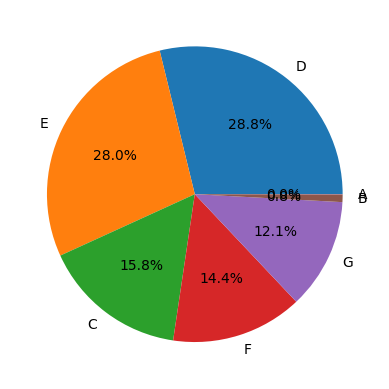

In [12]:
import matplotlib.pyplot as plt

values = list(df.etiquette_dpe_ademe.value_counts().values)
categ = list(df.etiquette_dpe_ademe.value_counts().index)

plt.pie(values, labels=categ, autopct='%1.1f%%') #, colors=['blue', 'red', 'green', 'purple'])
plt.show()

In [15]:
import mlflow

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.search_experiments()

[<Experiment: artifact_location='file:///C:/Users/gbeno/Documents/m2_deng/ydays/CHALLENGE-DPE-OPENDATA-UNIV/mlruns/545848974209619694', creation_time=1738332522104, experiment_id='545848974209619694', last_update_time=1738332522104, lifecycle_stage='active', name='1_modele_non_contraint_conso_enedis', tags={}>,
 <Experiment: artifact_location='file:///C:/Users/gbeno/Documents/m2_deng/ydays/CHALLENGE-DPE-OPENDATA-UNIV/mlruns/539077145957210469', creation_time=1737191755189, experiment_id='539077145957210469', last_update_time=1737191755189, lifecycle_stage='active', name='Exêrience_test_2025_01_18_01', tags={}>,
 <Experiment: artifact_location='file:///C:/Users/gbeno/Documents/m2_deng/ydays/CHALLENGE-DPE-OPENDATA-UNIV/mlruns/804884012945441034', creation_time=1737023458832, experiment_id='804884012945441034', last_update_time=1737023458832, lifecycle_stage='active', name='0_dataset_cleaning', tags={}>,
 <Experiment: artifact_location='file:///C:/Users/gbeno/Documents/m2_deng/ydays/CHALL

In [18]:
mlflow.search_runs(experiment_names=['1_modele_non_contraint_conso_enedis'])

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_duration,metrics.MAPE,metrics.R2_score,metrics.RMSE,...,params.model,params.num_samples,params.num_features,params.test_shape,tags.mlflow.log-model.history,tags.mlflow.source.git.commit,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.user,tags.mlflow.runName
0,39a61ff494944718ba87196a45ba6fda,545848974209619694,FINISHED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 15:03:26.051000+00:00,2025-01-31 15:07:05.009000+00:00,199.912222,0.3117,0.3026,0.7989,...,Pipeline,329340,10,"(65868, 10)","[{""run_id"": ""39a61ff494944718ba87196a45ba6fda""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,wise-conch-207
1,eacb50a00f4f40258cae16d1031dcbb4,545848974209619694,FINISHED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:58:19.245000+00:00,2025-01-31 15:01:56.584000+00:00,200.172359,0.3119,0.3027,0.7988,...,Pipeline,329340,10,"(65868, 10)","[{""run_id"": ""eacb50a00f4f40258cae16d1031dcbb4""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,smiling-flea-182
2,99025ac05e1d47d3a2fb0cfa3d95fd6c,545848974209619694,FAILED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:56:35.886000+00:00,2025-01-31 14:57:35.407000+00:00,48.982061,NaN,NaN,NaN,...,None,329340,10,"(65868, 10)","[{""run_id"": ""99025ac05e1d47d3a2fb0cfa3d95fd6c""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,industrious-cow-591
3,9c641f9088ce468b8fbad81df185b61a,545848974209619694,FINISHED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:49:35.533000+00:00,2025-01-31 14:50:50.992000+00:00,56.689312,0.3643,0.1178,0.8985,...,Pipeline,329340,10,"(65868, 10)","[{""run_id"": ""9c641f9088ce468b8fbad81df185b61a""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,polite-owl-681
4,2d962bb5ab4440919cc1b52f4706163b,545848974209619694,FAILED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:46:36.015000+00:00,2025-01-31 14:48:11.823000+00:00,NaN,NaN,NaN,NaN,...,None,329340,10,"(65868, 10)",None,f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,overjoyed-shrike-535
5,baaa0f2866f94ee2acea1b9df95d78f4,545848974209619694,FINISHED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:39:34.586000+00:00,2025-01-31 14:43:11.968000+00:00,199.768347,0.3117,0.3038,0.7982,...,Pipeline,329340,10,"(65868, 10)","[{""run_id"": ""baaa0f2866f94ee2acea1b9df95d78f4""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,adaptable-fox-63
6,e6e3c6bc5285478bb53b4b9c7685fc55,545848974209619694,FAILED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:35:13.977000+00:00,2025-01-31 14:38:53.612000+00:00,204.842916,NaN,NaN,NaN,...,None,329340,10,"(65868, 10)",None,f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,vaunted-skink-189
7,171fd5b089f84915807b16fef8251658,545848974209619694,FAILED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:30:51.847000+00:00,2025-01-31 14:31:51.690000+00:00,49.161848,NaN,NaN,NaN,...,None,329340,10,"(65868, 10)",None,f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,languid-stoat-142
8,77bfa64b10c04d9bb4ee7045d180defe,545848974209619694,FINISHED,file:///C:/Users/gbeno/Documents/m2_deng/ydays...,2025-01-31 14:08:44.032000+00:00,2025-01-31 14:12:16.169000+00:00,194.199263,0.3115,0.3044,0.7978,...,Pipeline,329340,10,"(65868, 10)","[{""run_id"": ""77bfa64b10c04d9bb4ee7045d180defe""...",f5c1400f9600aa0b15de785a1c3a53130d308a06,src/pipelines/train.py,LOCAL,gbeno,skillful-flea-733


In [24]:
# mlflow.sklearn.load_model("models:/ABC/latest") # le dernier model de ce nom
m_ = mlflow.sklearn.load_model("runs:/39a61ff494944718ba87196a45ba6fda/model_fitted") # ca lit dans le dossier mlruns
m_.named_steps['model'].best_estimator_

RandomForestRegressor(min_samples_split=10000)

In [25]:
m_.named_steps['model'].best_estimator_.feature_names_in_

array(['standard_scaler__conso_eclairage_e_finale_ademe',
       'standard_scaler__deperditions_murs_ademe',
       'standard_scaler__deperditions_ponts_thermiques_ademe',
       'standard_scaler__conso_chauffage_e_finale_ademe',
       'standard_scaler__deperditions_enveloppe_ademe',
       'standard_scaler__deperditions_baies_vitrees_ademe',
       'standard_scaler__deperditions_renouvellement_air_ademe',
       'standard_scaler__conso_ecs_e_finale_ademe',
       'ordinal_encoder__etiquette_dpe_ademe',
       'remainder__version_dpe_ademe'], dtype=object)